In [1]:
from __future__ import annotations

import platform
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn


# Konfigurasi reproducibility
SEED = 42
N_SPLITS = 5

# Mengurangi warning yang tidak relevan
warnings.filterwarnings("ignore", category=FutureWarning)

# Tampilan tabel pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# Tema visualisasi
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

# Warna konsisten untuk kedua kelas
COLOR_LOW_INCOME = "#2F6690"
COLOR_HIGH_INCOME = "#E07A5F"
COLOR_ACCENT = "#3D9970"
COLOR_MUTED = "#9AA5B1"

print("Python version       :", platform.python_version())
print("NumPy version        :", np.__version__)
print("pandas version       :", pd.__version__)
print("scikit-learn version :", sklearn.__version__)

Python version       : 3.13.2
NumPy version        : 2.4.0
pandas version       : 3.0.0
scikit-learn version : 1.8.0


In [ ]:
# Menentukan lokasi dataset secara portabel
candidate_directories = [
    Path.cwd() / "data",
    Path.cwd().parent / "data",
    Path.cwd(),
]

DATA_DIR = next(
    (
        directory
        for directory in candidate_directories
        if (directory / "train.csv").exists()
    ),
    None,
)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Folder data tidak ditemukan. Letakkan train.csv, test.csv, "
        "dan sample_submission.csv di folder data/."
    )

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

required_files = [TRAIN_PATH, TEST_PATH, SAMPLE_SUBMISSION_PATH]
missing_files = [path.name for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        f"File berikut belum ditemukan: {missing_files}"
    )

print("Folder dataset:", DATA_DIR.resolve())
print("Seluruh file dataset berhasil ditemukan.")


In [3]:
train_raw = pd.read_csv(TRAIN_PATH)

if "income" not in train_raw.columns:
    raise ValueError(
        "Kolom target 'income' tidak ditemukan pada train.csv."
    )

print("Ukuran train :", train_raw.shape)
print("Jumlah baris :", train_raw.shape[0])
print("Jumlah kolom :", train_raw.shape[1])

display(train_raw.head())

Ukuran train : (39073, 15)
Jumlah baris : 39073
Jumlah kolom : 15


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,37,Private,193106,Bachelors,13,Never-married,Sales,Not-in-family,White,Female,0,0,30,United-States,<=50K.
1,56,Self-emp-inc,216636,12th,8,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1651,40,United-States,<=50K
2,53,Private,126977,HS-grad,9,Separated,Craft-repair,Not-in-family,White,Male,0,0,35,United-States,<=50K
3,72,Private,205343,11th,7,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
4,46,State-gov,106705,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,38,United-States,<=50K


In [4]:
print("Informasi dataset train:\n")
train_raw.info()

print("\nDaftar kolom:")
for number, column in enumerate(train_raw.columns, start=1):
    print(f"{number:2}. {column}")

print("\nJumlah kolom berdasarkan tipe data:")
print(train_raw.dtypes.value_counts())

Informasi dataset train:

<class 'pandas.DataFrame'>
RangeIndex: 39073 entries, 0 to 39072
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             39073 non-null  int64
 1   workclass       38304 non-null  str  
 2   fnlwgt          39073 non-null  int64
 3   education       39073 non-null  str  
 4   education-num   39073 non-null  int64
 5   marital-status  39073 non-null  str  
 6   occupation      38302 non-null  str  
 7   relationship    39073 non-null  str  
 8   race            39073 non-null  str  
 9   sex             39073 non-null  str  
 10  capital-gain    39073 non-null  int64
 11  capital-loss    39073 non-null  int64
 12  hours-per-week  39073 non-null  int64
 13  native-country  38851 non-null  str  
 14  income          39073 non-null  str  
dtypes: int64(6), str(9)
memory usage: 7.5 MB

Daftar kolom:
 1. age
 2. workclass
 3. fnlwgt
 4. education
 5. education-num
 6. marital-status


In [5]:
raw_target_summary = (
    train_raw["income"]
    .value_counts(dropna=False)
    .rename_axis("raw_income")
    .reset_index(name="jumlah")
)

raw_target_summary["persentase"] = (
    raw_target_summary["jumlah"] / len(train_raw)
)

print("Nilai unik target sebelum normalisasi:")
display(raw_target_summary)

print(
    "Jumlah label target yang terdeteksi:",
    train_raw["income"].nunique(dropna=False),
)

Nilai unik target sebelum normalisasi:


,raw_income,jumlah,persentase
0,<=50K,19733,0.5050
1,<=50K.,9991,0.2557
2,>50K,6306,0.1614
3,>50K.,3043,0.0779


Jumlah label target yang terdeteksi: 4


In [7]:
def normalize_target(series: pd.Series) -> pd.Series:
    """
    Menormalisasi label income menjadi tepat dua kelas:
    <=50K dan >50K.
    """
    
    normalized = (
        series
        .astype("string")
        .str.strip()
        .str.rstrip(".")
    )

    allowed_labels = {"<=50K", ">50K"}

    unexpected_labels = sorted(
        set(normalized.dropna().unique()) - allowed_labels
    )

    if unexpected_labels:
        raise ValueError(
            f"Ditemukan label target yang tidak dikenal: "
            f"{unexpected_labels}"
        )

    if normalized.isna().any():
        raise ValueError(
            "Ditemukan nilai kosong pada kolom target."
        )

    return normalized


income_clean = normalize_target(train_raw["income"])

# Encoding untuk keperluan Machine Learning
y = (
    income_clean
    .map({
        "<=50K": 0,
        ">50K": 1,
    })
    .astype("int8")
)

target_counts = (
    income_clean
    .value_counts()
    .reindex(["<=50K", ">50K"])
)

target_summary = pd.DataFrame({
    "jumlah": target_counts,
    "persentase": target_counts / len(train_raw),
})

display(target_summary)

assert set(income_clean.unique()) == {"<=50K", ">50K"}
assert set(y.unique()) == {0, 1}
assert len(y) == len(train_raw)

,jumlah,persentase
income,,
<=50K,29724,0.7607
>50K,9349,0.2393


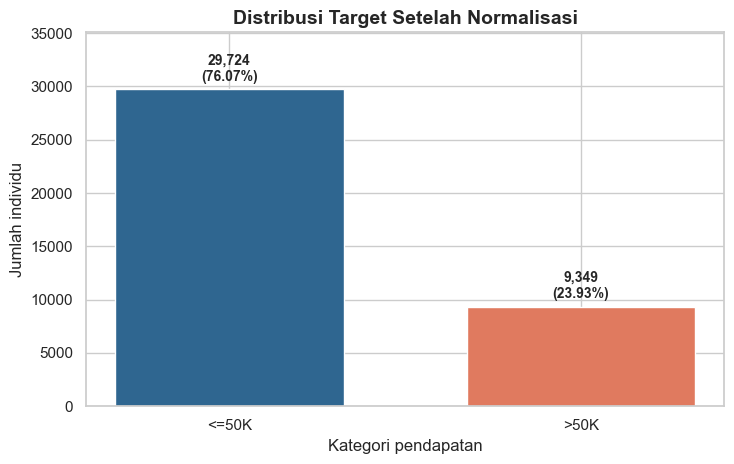

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))

class_order = ["<=50K", ">50K"]
class_colors = [
    COLOR_LOW_INCOME,
    COLOR_HIGH_INCOME,
]

bars = ax.bar(
    class_order,
    target_counts.loc[class_order],
    color=class_colors,
    width=0.65,
)

for bar, count in zip(
    bars,
    target_counts.loc[class_order],
):
    percentage = count / len(train_raw)

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{count:,}\n({percentage:.2%})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title(
    "Distribusi Target Setelah Normalisasi",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Kategori pendapatan")
ax.set_ylabel("Jumlah individu")
ax.set_ylim(0, target_counts.max() * 1.18)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import accuracy_score, f1_score


# Baseline yang selalu memprediksi kelas mayoritas, yaitu <=50K
dummy_prediction = np.zeros(
    len(y),
    dtype="int8",
)

dummy_accuracy = accuracy_score(
    y,
    dummy_prediction,
)

dummy_f1_macro = f1_score(
    y,
    dummy_prediction,
    average="macro",
    zero_division=0,
)

print(
    f"Dummy accuracy : {dummy_accuracy:.4f} "
    f"({dummy_accuracy:.2%})"
)

print(
    f"Dummy F1-macro : {dummy_f1_macro:.4f}"
)

Dummy accuracy : 0.7607 (76.07%)
Dummy F1-macro : 0.4321


In [10]:
# is_string_dtype digunakan agar kompatibel dengan:
# - pandas lama: kategorikal terbaca sebagai object
# - pandas 3.0: kategorikal terbaca sebagai str

categorical_columns = [
    column
    for column in train_raw.columns
    if pd.api.types.is_string_dtype(
        train_raw[column].dtype
    )
]

categorical_feature_columns = [
    column
    for column in categorical_columns
    if column != "income"
]

print("Kolom kategorikal:")
for column in categorical_feature_columns:
    print(f"- {column}")

print(
    "\nJumlah kolom kategorikal fitur:",
    len(categorical_feature_columns),
)

Kolom kategorikal:
- workclass
- education
- marital-status
- occupation
- relationship
- race
- sex
- native-country

Jumlah kolom kategorikal fitur: 8


In [11]:
nan_counts = (
    train_raw
    .isna()
    .sum()
    .sort_values(ascending=False)
)

nan_summary = (
    nan_counts[nan_counts > 0]
    .rename("jumlah_nan")
    .to_frame()
)

nan_summary["persentase"] = (
    nan_summary["jumlah_nan"] / len(train_raw)
)

print("Kolom yang memiliki NaN:")
display(nan_summary)

Kolom yang memiliki NaN:


,jumlah_nan,persentase
occupation,771,0.0197
workclass,769,0.0197
native-country,222,0.0057


In [12]:
KEY_MISSING_COLUMNS = [
    "workclass",
    "occupation",
    "native-country",
]


def summarize_invalid_values(
    dataframe: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    """
    Menghitung NaN, tanda tanya, string kosong,
    dan total nilai tidak valid.
    """

    records = []

    for column in columns:
        original = dataframe[column]

        stripped = (
            original
            .astype("string")
            .str.strip()
        )

        null_mask = original.isna()

        question_mask = (
            stripped
            .eq("?")
            .fillna(False)
        )

        empty_mask = (
            stripped
            .eq("")
            .fillna(False)
        )

        invalid_mask = (
            null_mask
            | question_mask
            | empty_mask
        )

        records.append({
            "column": column,
            "null": int(null_mask.sum()),
            "question_mark": int(question_mask.sum()),
            "empty_string": int(empty_mask.sum()),
            "total_invalid": int(invalid_mask.sum()),
            "invalid_rate": invalid_mask.mean(),
        })

    return (
        pd.DataFrame(records)
        .set_index("column")
    )


invalid_summary = summarize_invalid_values(
    train_raw,
    KEY_MISSING_COLUMNS,
)

display(invalid_summary)

,null,question_mark,empty_string,total_invalid,invalid_rate
column,,,,,
workclass,769,1464,0,2233,0.0571
occupation,771,1470,0,2241,0.0574
native-country,222,466,0,688,0.0176


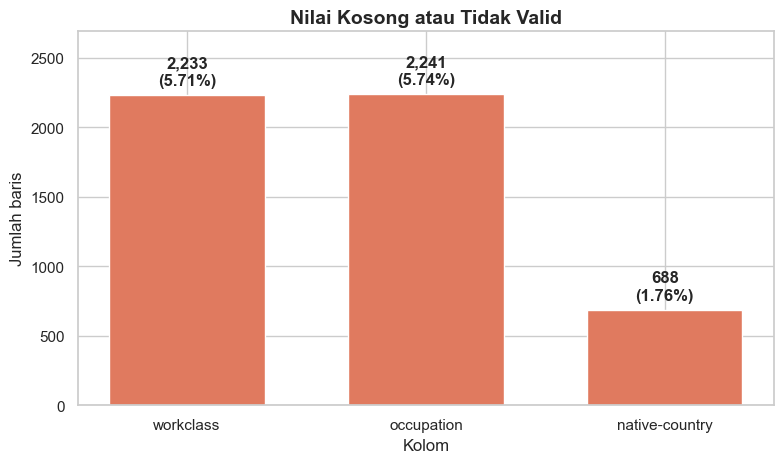

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.8))

bars = ax.bar(
    invalid_summary.index,
    invalid_summary["total_invalid"],
    color=COLOR_HIGH_INCOME,
    width=0.65,
)

for bar, total, rate in zip(
    bars,
    invalid_summary["total_invalid"],
    invalid_summary["invalid_rate"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{total:,}\n({rate:.2%})",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax.set_title(
    "Nilai Kosong atau Tidak Valid",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Kolom")
ax.set_ylabel("Jumlah baris")
ax.set_ylim(
    0,
    invalid_summary["total_invalid"].max() * 1.20,
)

plt.tight_layout()
plt.show()

In [14]:
def create_invalid_mask(
    series: pd.Series,
) -> pd.Series:
    stripped = (
        series
        .astype("string")
        .str.strip()
    )

    return (
        series.isna()
        | stripped.isin(["?", ""])
    )


workclass_invalid = create_invalid_mask(
    train_raw["workclass"]
)

occupation_invalid = create_invalid_mask(
    train_raw["occupation"]
)

country_invalid = create_invalid_mask(
    train_raw["native-country"]
)

missing_pattern = pd.DataFrame({
    "pola": [
        "Workclass dan occupation invalid",
        "Hanya workclass invalid",
        "Hanya occupation invalid",
        "Keduanya valid",
    ],
    "jumlah": [
        int(
            (
                workclass_invalid
                & occupation_invalid
            ).sum()
        ),
        int(
            (
                workclass_invalid
                & ~occupation_invalid
            ).sum()
        ),
        int(
            (
                ~workclass_invalid
                & occupation_invalid
            ).sum()
        ),
        int(
            (
                ~workclass_invalid
                & ~occupation_invalid
            ).sum()
        ),
    ],
})

display(missing_pattern)

any_key_invalid = (
    workclass_invalid
    | occupation_invalid
    | country_invalid
)

all_key_invalid = (
    workclass_invalid
    & occupation_invalid
    & country_invalid
)

print(
    "Baris dengan minimal satu invalid:",
    int(any_key_invalid.sum()),
)

print(
    "Baris dengan ketiganya invalid:",
    int(all_key_invalid.sum()),
)

assert missing_pattern["jumlah"].sum() == len(train_raw)

,pola,jumlah
0,Workclass dan occupation invalid,2233
1,Hanya workclass invalid,0
2,Hanya occupation invalid,8
3,Keduanya valid,36832


Baris dengan minimal satu invalid: 2890
Baris dengan ketiganya invalid: 39


In [15]:
unique_records = []

for column in categorical_feature_columns:
    stripped = (
        train_raw[column]
        .astype("string")
        .str.strip()
    )

    invalid_mask = (
        stripped.isna()
        | stripped.isin(["?", ""])
    )

    valid_values = stripped[~invalid_mask]

    unique_records.append({
        "column": column,
        "raw_unique_non_null": (
            train_raw[column]
            .nunique(dropna=True)
        ),
        "invalid_rows": int(invalid_mask.sum()),
        "valid_unique": valid_values.nunique(),
        "unique_after_unknown": (
            valid_values.nunique()
            + int(invalid_mask.any())
        ),
    })

categorical_unique_summary = (
    pd.DataFrame(unique_records)
    .set_index("column")
)

display(categorical_unique_summary)

,raw_unique_non_null,invalid_rows,valid_unique,unique_after_unknown
column,,,,
workclass,9,2233,8,9
education,16,0,16,16
marital-status,7,0,7,7
occupation,15,2241,14,15
relationship,6,0,6,6
race,5,0,5,5
sex,2,0,2,2
native-country,42,688,41,42


In [16]:
exact_duplicate_count = int(
    train_raw.duplicated().sum()
)

feature_duplicate_count = int(
    train_raw
    .drop(columns="income")
    .duplicated()
    .sum()
)

duplicate_summary = pd.DataFrame({
    "pemeriksaan": [
        "Duplikat persis termasuk target",
        "Duplikat berdasarkan seluruh fitur",
    ],
    "jumlah": [
        exact_duplicate_count,
        feature_duplicate_count,
    ],
    "persentase": [
        exact_duplicate_count / len(train_raw),
        feature_duplicate_count / len(train_raw),
    ],
})

display(duplicate_summary)

print("Contoh baris yang terdeteksi duplikat:")

display(
    train_raw.loc[
        train_raw.duplicated(
            keep=False
        )
    ].head(10)
)

,pemeriksaan,jumlah,persentase
0,Duplikat persis termasuk target,21,0.0005
1,Duplikat berdasarkan seluruh fitur,35,0.0009


Contoh baris yang terdeteksi duplikat:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
706,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
735,37,Private,52870,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K.
805,38,Private,207202,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,48,United-States,>50K
4821,49,Self-emp-not-inc,43479,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
5224,44,Private,367749,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,45,Mexico,<=50K
5858,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
5895,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
7599,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
7848,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
8777,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [17]:
education_to_number = (
    train_raw
    .groupby("education")["education-num"]
    .nunique()
)

number_to_education = (
    train_raw
    .groupby("education-num")["education"]
    .nunique()
)

education_mapping = (
    train_raw[
        [
            "education",
            "education-num",
        ]
    ]
    .drop_duplicates()
    .sort_values("education-num")
    .reset_index(drop=True)
)

display(education_mapping)

print(
    "Maksimum education-num per education:",
    education_to_number.max(),
)

print(
    "Maksimum education per education-num:",
    number_to_education.max(),
)

assert education_to_number.max() == 1
assert number_to_education.max() == 1

,education,education-num
0,Preschool,1
1,1st-4th,2
2,5th-6th,3
3,7th-8th,4
4,9th,5
5,10th,6
6,11th,7
7,12th,8
8,HS-grad,9
9,Some-college,10


Maksimum education-num per education: 1
Maksimum education per education-num: 1


In [18]:
numeric_feature_columns = (
    train_raw
    .select_dtypes(include="number")
    .columns
    .tolist()
)

print("Fitur numerik:")

for column in numeric_feature_columns:
    print(f"- {column}")

numeric_descriptive_summary = (
    train_raw[numeric_feature_columns]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .T
)

display(numeric_descriptive_summary)

Fitur numerik:
- age
- fnlwgt
- education-num
- capital-gain
- capital-loss
- hours-per-week


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,"39,073.0000",38.6435,13.6856,17.0000,17.0000,19.0000,28.0000,37.0000,48.0000,63.0000,74.0000,90.0000
fnlwgt,"39,073.0000","189,992.2388","105,476.8444","13,769.0000","27,126.3200","39,609.6000","117,767.0000","178,615.0000","238,329.0000","379,523.2000","508,004.0800","1,490,400.0000"
education-num,"39,073.0000",10.0698,2.5744,1.0000,3.0000,5.0000,9.0000,10.0000,12.0000,14.0000,16.0000,16.0000
capital-gain,"39,073.0000","1,038.0405","7,204.9531",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"4,865.0000","15,024.0000","99,999.0000"
capital-loss,"39,073.0000",86.8079,401.2768,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"1,980.0000","4,356.0000"
hours-per-week,"39,073.0000",40.4769,12.4013,1.0000,8.0000,17.6000,40.0000,40.0000,45.0000,60.0000,80.0000,99.0000


In [19]:
numeric_range_checks = pd.DataFrame({
    "pemeriksaan": [
        "Age tidak negatif",
        "fnlwgt bernilai positif",
        "Education-num berada pada 1-16",
        "Capital-gain tidak negatif",
        "Capital-loss tidak negatif",
        "Hours-per-week berada pada 1-168",
    ],
    "hasil": [
        train_raw["age"].ge(0).all(),
        train_raw["fnlwgt"].gt(0).all(),
        train_raw["education-num"].between(1, 16).all(),
        train_raw["capital-gain"].ge(0).all(),
        train_raw["capital-loss"].ge(0).all(),
        train_raw["hours-per-week"].between(1, 168).all(),
    ],
})

display(numeric_range_checks)

assert numeric_range_checks["hasil"].all()

,pemeriksaan,hasil
0,Age tidak negatif,True
1,fnlwgt bernilai positif,True
2,Education-num berada pada 1-16,True
3,Capital-gain tidak negatif,True
4,Capital-loss tidak negatif,True
5,Hours-per-week berada pada 1-168,True


In [20]:
eda_numeric = (
    train_raw[numeric_feature_columns]
    .copy()
)

eda_numeric["income"] = income_clean.to_numpy()

target_order = [
    "<=50K",
    ">50K",
]

target_palette = {
    "<=50K": COLOR_LOW_INCOME,
    ">50K": COLOR_HIGH_INCOME,
}

print("Ukuran dataframe EDA:", eda_numeric.shape)

display(eda_numeric.head())

Ukuran dataframe EDA: (39073, 7)


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
0,37,193106,13,0,0,30,<=50K
1,56,216636,8,0,1651,40,<=50K
2,53,126977,9,0,0,35,<=50K
3,72,205343,7,0,0,40,<=50K
4,46,106705,14,0,0,38,<=50K


In [21]:
selected_numeric_columns = [
    "age",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
]

numeric_summary_by_income = (
    eda_numeric
    .groupby("income")[
        selected_numeric_columns
    ]
    .agg([
        "mean",
        "median",
    ])
    .reindex(target_order)
)

display(
    numeric_summary_by_income.round(2)
)

age         education-num         capital-gain        capital-loss  \
          mean  median          mean  median         mean median         mean   
income                                                                          
<=50K  36.8800 34.0000        9.5900  9.0000     144.1800 0.0000      54.0000   
>50K   44.2400 43.0000       11.6100 12.0000   3,879.9700 0.0000     191.1200   

              hours-per-week          
       median           mean  median  
income                                
<=50K  0.0000        38.8700 40.0000  
>50K   0.0000        45.5800 40.0000

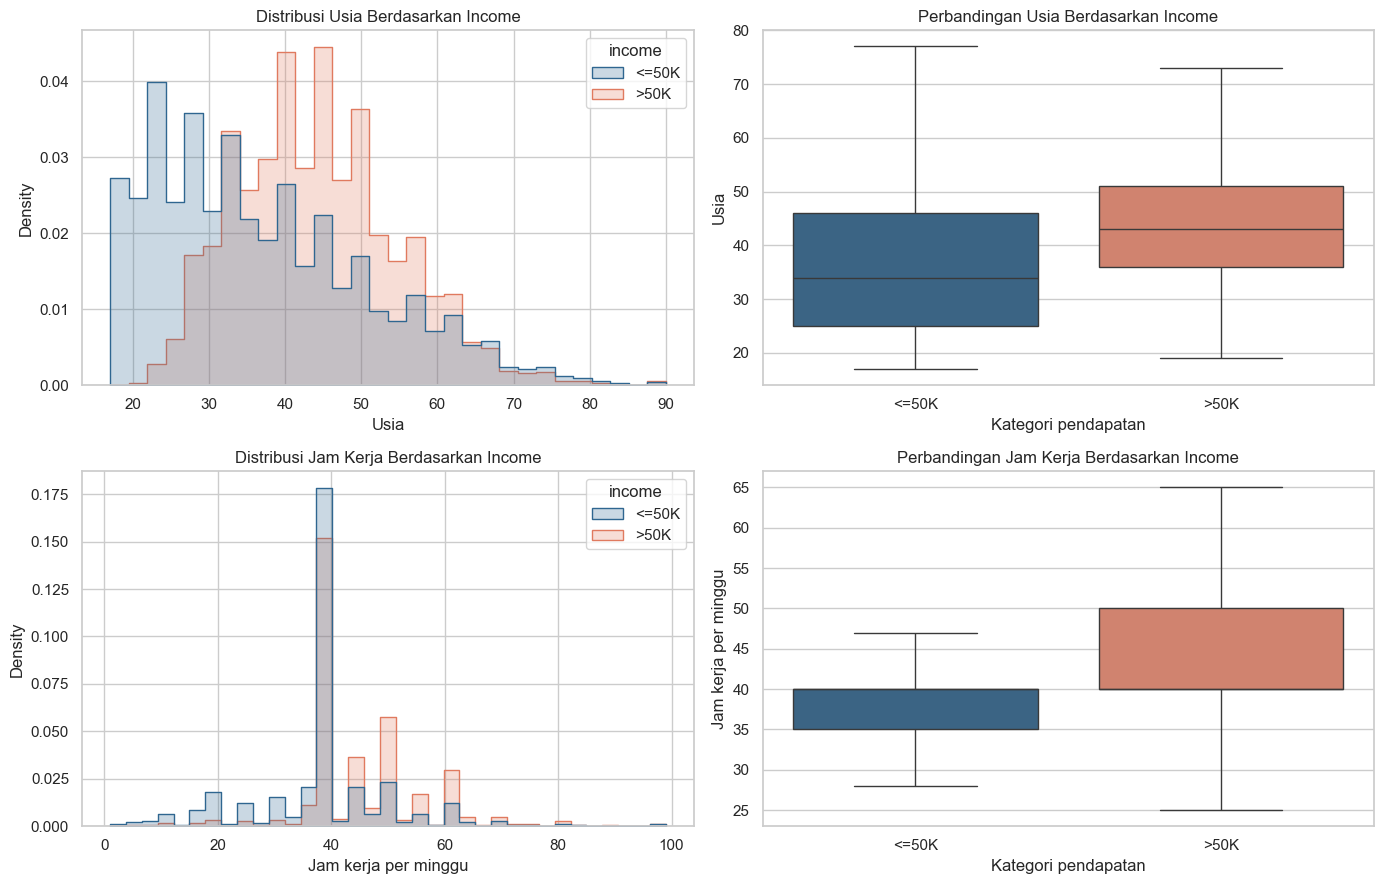

In [22]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
)

# Distribusi usia
sns.histplot(
    data=eda_numeric,
    x="age",
    hue="income",
    hue_order=target_order,
    palette=target_palette,
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    alpha=0.25,
    ax=axes[0, 0],
)

axes[0, 0].set_title(
    "Distribusi Usia Berdasarkan Income"
)
axes[0, 0].set_xlabel("Usia")
axes[0, 0].set_ylabel("Density")

# Boxplot usia
sns.boxplot(
    data=eda_numeric,
    x="income",
    y="age",
    order=target_order,
    hue="income",
    hue_order=target_order,
    palette=target_palette,
    dodge=False,
    legend=False,
    showfliers=False,
    ax=axes[0, 1],
)

axes[0, 1].set_title(
    "Perbandingan Usia Berdasarkan Income"
)
axes[0, 1].set_xlabel("Kategori pendapatan")
axes[0, 1].set_ylabel("Usia")

# Distribusi jam kerja
sns.histplot(
    data=eda_numeric,
    x="hours-per-week",
    hue="income",
    hue_order=target_order,
    palette=target_palette,
    bins=35,
    stat="density",
    common_norm=False,
    element="step",
    alpha=0.25,
    ax=axes[1, 0],
)

axes[1, 0].set_title(
    "Distribusi Jam Kerja Berdasarkan Income"
)
axes[1, 0].set_xlabel("Jam kerja per minggu")
axes[1, 0].set_ylabel("Density")

# Boxplot jam kerja
sns.boxplot(
    data=eda_numeric,
    x="income",
    y="hours-per-week",
    order=target_order,
    hue="income",
    hue_order=target_order,
    palette=target_palette,
    dodge=False,
    legend=False,
    showfliers=False,
    ax=axes[1, 1],
)

axes[1, 1].set_title(
    "Perbandingan Jam Kerja Berdasarkan Income"
)
axes[1, 1].set_xlabel("Kategori pendapatan")
axes[1, 1].set_ylabel("Jam kerja per minggu")

plt.tight_layout()
plt.show()

In [23]:
education_num_analysis = (
    pd.DataFrame({
        "education-num": train_raw["education-num"],
        "is_high_income": y,
    })
    .groupby("education-num")
    .agg(
        jumlah=(
            "is_high_income",
            "size",
        ),
        jumlah_diatas_50K=(
            "is_high_income",
            "sum",
        ),
        proporsi_diatas_50K=(
            "is_high_income",
            "mean",
        ),
    )
    .reset_index()
)

display(education_num_analysis)

,education-num,jumlah,jumlah_diatas_50K,proporsi_diatas_50K
0,1,62,0,0.0000
1,2,213,7,0.0329
2,3,427,20,0.0468
3,4,756,45,0.0595
4,5,611,37,0.0606
5,6,1108,64,0.0578
6,7,1451,73,0.0503
7,8,532,38,0.0714
8,9,12582,1990,0.1582
9,10,8739,1677,0.1919


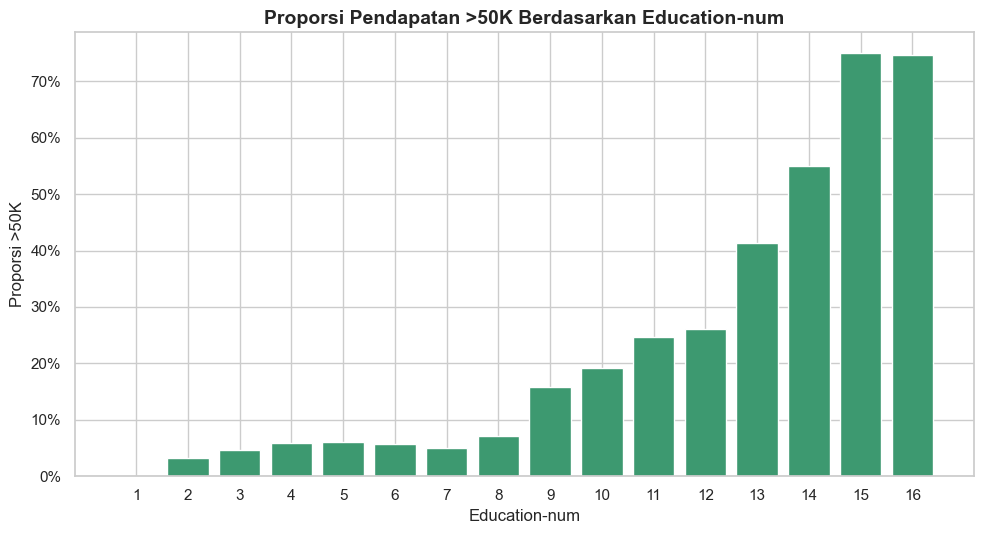

In [24]:
fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

bars = ax.bar(
    education_num_analysis["education-num"],
    education_num_analysis["proporsi_diatas_50K"],
    color=COLOR_ACCENT,
)

ax.set_title(
    "Proporsi Pendapatan >50K Berdasarkan Education-num",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Education-num")
ax.set_ylabel("Proporsi >50K")

ax.yaxis.set_major_formatter(
    lambda value, position: f"{value:.0%}"
)

ax.set_xticks(
    education_num_analysis["education-num"]
)

plt.tight_layout()
plt.show()

In [25]:
capital_columns = [
    "capital-gain",
    "capital-loss",
]

capital_records = []

for column in capital_columns:
    values = train_raw[column]

    positive_values = values[
        values > 0
    ]

    capital_records.append({
        "column": column,
        "zero_count": int(
            values.eq(0).sum()
        ),
        "zero_rate": values.eq(0).mean(),
        "positive_count": int(
            values.gt(0).sum()
        ),
        "positive_rate": values.gt(0).mean(),
        "mean_all": values.mean(),
        "median_all": values.median(),
        "median_positive": (
            positive_values.median()
        ),
        "maximum": values.max(),
    })

capital_summary = (
    pd.DataFrame(capital_records)
    .set_index("column")
)

display(capital_summary)

,zero_count,zero_rate,positive_count,positive_rate,mean_all,median_all,median_positive,maximum
column,,,,,,,,
capital-gain,35883,0.9184,3190,0.0816,"1,038.0405",0.0000,"7,298.0000",99999
capital-loss,37259,0.9536,1814,0.0464,86.8079,0.0000,"1,887.0000",4356


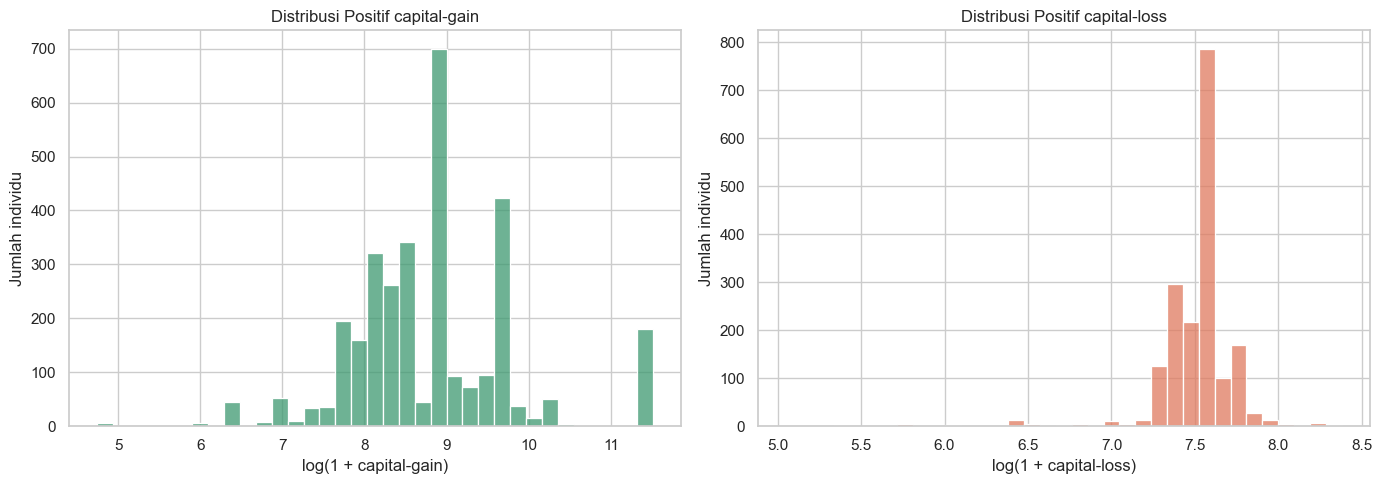

In [26]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

for ax, column, color in zip(
    axes,
    capital_columns,
    [
        COLOR_ACCENT,
        COLOR_HIGH_INCOME,
    ],
):
    positive_values = train_raw.loc[
        train_raw[column] > 0,
        column,
    ]

    sns.histplot(
        np.log1p(positive_values),
        bins=35,
        color=color,
        ax=ax,
    )

    ax.set_title(
        f"Distribusi Positif {column}"
    )
    ax.set_xlabel(
        f"log(1 + {column})"
    )
    ax.set_ylabel("Jumlah individu")

plt.tight_layout()
plt.show()

In [28]:
def create_iqr_outlier_summary(
    dataframe: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    records = []

    for column in columns:
        values = dataframe[column]

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_mask = (
            values.lt(lower_bound)
            | values.gt(upper_bound)
        )

        records.append({
            "column": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": int(
                outlier_mask.sum()
            ),
            "outlier_rate": (
                outlier_mask.mean()
            ),
        })

    return (
        pd.DataFrame(records)
        .set_index("column")
    )


iqr_outlier_summary = (
    create_iqr_outlier_summary(
        train_raw,
        numeric_feature_columns,
    )
)

display(iqr_outlier_summary)

,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_rate
column,,,,,,,
age,28.0000,48.0000,20.0000,-2.0000,78.0000,172,0.0044
fnlwgt,"117,767.0000","238,329.0000","120,562.0000","-63,076.0000","419,172.0000",1140,0.0292
education-num,9.0000,12.0000,3.0000,4.5000,16.5000,1458,0.0373
capital-gain,0.0000,0.0000,0.0000,0.0000,0.0000,3190,0.0816
capital-loss,0.0000,0.0000,0.0000,0.0000,0.0000,1814,0.0464
hours-per-week,40.0000,45.0000,5.0000,32.5000,52.5000,10798,0.2764


In [29]:
numeric_correlation_data = (
    train_raw[numeric_feature_columns]
    .copy()
)

numeric_correlation_data[
    "income_binary"
] = y.to_numpy()

correlation_matrix = (
    numeric_correlation_data
    .corr()
)

correlation_with_target = (
    correlation_matrix["income_binary"]
    .drop("income_binary")
    .sort_values(ascending=False)
    .rename("correlation_with_income")
    .to_frame()
)

display(correlation_with_target)

,correlation_with_income
education-num,0.3354
hours-per-week,0.2306
age,0.2293
capital-gain,0.2212
capital-loss,0.1458
fnlwgt,-0.0056


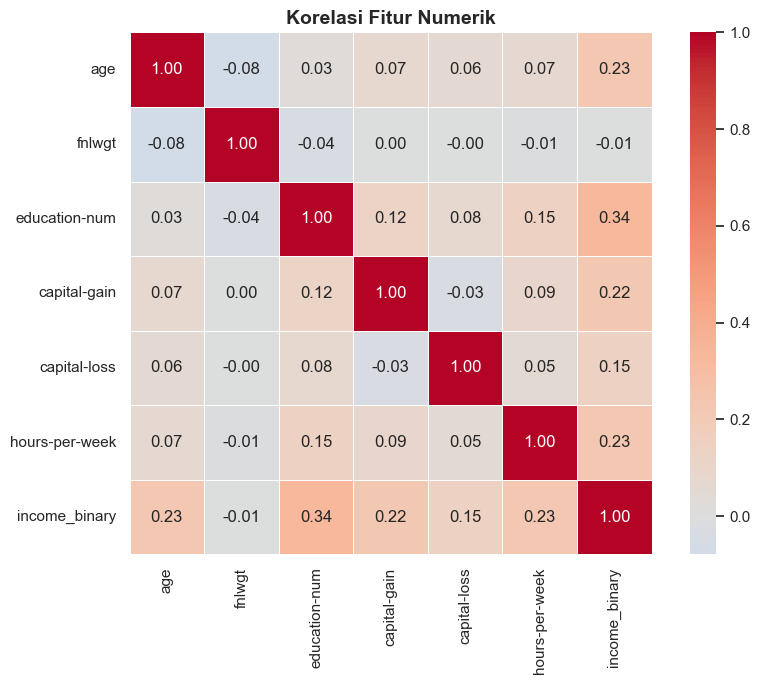

In [30]:
fig, ax = plt.subplots(
    figsize=(9, 7)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)

ax.set_title(
    "Korelasi Fitur Numerik",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

In [31]:
def clean_categorical_for_eda(series):
    """
    Membersihkan satu kolom kategorikal untuk kebutuhan EDA.

    Nilai NaN, tanda tanya, dan string kosong akan
    digabungkan menjadi kategori 'Unknown'.
    """
    return (
        series
        .astype("string")
        .str.strip()
        .replace({
            "?": pd.NA,
            "": pd.NA,
        })
        .fillna("Unknown")
    )


# Membuat salinan khusus EDA agar train_raw tetap utuh
eda_categorical = (
    train_raw[categorical_feature_columns]
    .copy()
)

for column in categorical_feature_columns:
    eda_categorical[column] = clean_categorical_for_eda(
        eda_categorical[column]
    )


# Menambahkan target yang sudah dinormalisasi
eda_categorical["income"] = income_clean.to_numpy()

# Versi numerik target:
# 0 = <=50K
# 1 = >50K
eda_categorical["is_high_income"] = y.to_numpy()


print(
    "Ukuran dataframe EDA kategorikal:",
    eda_categorical.shape,
)

display(eda_categorical.head())

Ukuran dataframe EDA kategorikal: (39073, 10)


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income,is_high_income
0,Private,Bachelors,Never-married,Sales,Not-in-family,White,Female,United-States,<=50K,0
1,Self-emp-inc,12th,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K,0
2,Private,HS-grad,Separated,Craft-repair,Not-in-family,White,Male,United-States,<=50K,0
3,Private,11th,Widowed,Adm-clerical,Unmarried,White,Female,United-States,<=50K,0
4,State-gov,Masters,Never-married,Exec-managerial,Not-in-family,White,Female,United-States,<=50K,0


In [32]:
categorical_quality_records = []

for column in categorical_feature_columns:
    categorical_quality_records.append({
        "column": column,
        "jumlah_kategori": (
            eda_categorical[column]
            .nunique(dropna=False)
        ),
        "jumlah_unknown": int(
            eda_categorical[column]
            .eq("Unknown")
            .sum()
        ),
        "jumlah_nan": int(
            eda_categorical[column]
            .isna()
            .sum()
        ),
    })


categorical_quality_summary = (
    pd.DataFrame(categorical_quality_records)
    .set_index("column")
)

display(categorical_quality_summary)


# Pemeriksaan otomatis
assert len(eda_categorical) == len(train_raw)

assert (
    eda_categorical[
        categorical_feature_columns
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

assert set(
    eda_categorical["income"].unique()
) == {"<=50K", ">50K"}

assert set(
    eda_categorical["is_high_income"].unique()
) == {0, 1}

print("Seluruh pemeriksaan data kategorikal berhasil.")

,jumlah_kategori,jumlah_unknown,jumlah_nan
column,,,
workclass,9,2233,0
education,16,0,0
marital-status,7,0,0
occupation,15,2241,0
relationship,6,0,0
race,5,0,0
sex,2,0,0
native-country,42,688,0


Seluruh pemeriksaan data kategorikal berhasil.


In [38]:
def summarize_categorical_feature(data, feature):
    """
    Menghitung jumlah observasi dan proporsi target >50K
    untuk setiap kategori pada sebuah fitur.
    """
    summary = (
        data
        .groupby(
            feature,
            dropna=False,
            observed=False,
        )
        .agg(
            jumlah=(
                "is_high_income",
                "size",
            ),
            jumlah_diatas_50K=(
                "is_high_income",
                "sum",
            ),
            proporsi_diatas_50K=(
                "is_high_income",
                "mean",
            ),
        )
    )

    summary["persentase_data"] = (
        summary["jumlah"] / len(data)
    )

    summary = (
        summary[
            [
                "jumlah",
                "persentase_data",
                "jumlah_diatas_50K",
                "proporsi_diatas_50K",
            ]
        ]
        .sort_values(
            [
                "proporsi_diatas_50K",
                "jumlah",
            ],
            ascending=[
                False,
                False,
            ],
        )
    )

    return summary

In [39]:
categorical_summaries = {
    column: summarize_categorical_feature(
        eda_categorical,
        column,
    )
    for column in categorical_feature_columns
}


categorical_reconciliation = pd.DataFrame({
    "jumlah_kategori": {
        column: len(summary)
        for column, summary
        in categorical_summaries.items()
    },
    "total_baris": {
        column: int(summary["jumlah"].sum())
        for column, summary
        in categorical_summaries.items()
    },
})


display(categorical_reconciliation)


assert (
    categorical_reconciliation["total_baris"]
    .eq(len(eda_categorical))
    .all()
)

print(
    "Seluruh ringkasan kategorikal "
    "merekonsiliasi ke",
    f"{len(eda_categorical):,}",
    "baris.",
)

,jumlah_kategori,total_baris
workclass,9,39073
education,16,39073
marital-status,7,39073
occupation,15,39073
relationship,6,39073
race,5,39073
sex,2,39073
native-country,42,39073


Seluruh ringkasan kategorikal merekonsiliasi ke 39,073 baris.


In [40]:
print("Ringkasan fitur workclass:")

display(
    categorical_summaries["workclass"]
    .style
    .format({
        "jumlah": "{:,.0f}",
        "persentase_data": "{:.2%}",
        "jumlah_diatas_50K": "{:,.0f}",
        "proporsi_diatas_50K": "{:.2%}",
    })
)


print("\nRingkasan fitur occupation:")

display(
    categorical_summaries["occupation"]
    .style
    .format({
        "jumlah": "{:,.0f}",
        "persentase_data": "{:.2%}",
        "jumlah_diatas_50K": "{:,.0f}",
        "proporsi_diatas_50K": "{:.2%}",
    })
)

Ringkasan fitur workclass:


,jumlah,persentase_data,jumlah_diatas_50K,proporsi_diatas_50K
workclass,,,,
Self-emp-inc,"1,363",3.49%,747,54.81%
Federal-gov,"1,150",2.94%,450,39.13%
Local-gov,"2,535",6.49%,769,30.34%
Self-emp-not-inc,"3,068",7.85%,855,27.87%
State-gov,"1,556",3.98%,421,27.06%
Private,"27,141",69.46%,"5,894",21.72%
Without-pay,19,0.05%,2,10.53%
Unknown,"2,233",5.71%,211,9.45%
Never-worked,8,0.02%,0,0.00%



Ringkasan fitur occupation:


,jumlah,persentase_data,jumlah_diatas_50K,proporsi_diatas_50K
occupation,,,,
Exec-managerial,"4,893",12.52%,"2,312",47.25%
Prof-specialty,"4,915",12.58%,"2,242",45.62%
Armed-Forces,14,0.04%,5,35.71%
Protective-serv,806,2.06%,257,31.89%
Tech-support,"1,124",2.88%,321,28.56%
Sales,"4,413",11.29%,"1,200",27.19%
Craft-repair,"4,872",12.47%,"1,102",22.62%
Transport-moving,"1,908",4.88%,399,20.91%
Adm-clerical,"4,466",11.43%,611,13.68%


In [41]:
def plot_categorical_high_income_rate(
    summary,
    feature,
    ax,
    color,
):
    """
    Membuat horizontal bar chart proporsi pendapatan >50K.
    """
    plot_data = (
        summary
        .sort_values(
            "proporsi_diatas_50K",
            ascending=True,
        )
    )

    bars = ax.barh(
        plot_data.index.astype(str),
        plot_data["proporsi_diatas_50K"],
        color=color,
        alpha=0.88,
    )

    overall_rate = y.mean()

    ax.axvline(
        overall_rate,
        color=COLOR_MUTED,
        linestyle="--",
        linewidth=1.5,
        label=(
            "Proporsi keseluruhan "
            f"({overall_rate:.2%})"
        ),
    )

    maximum_rate = (
        plot_data["proporsi_diatas_50K"]
        .max()
    )

    x_limit = min(
        1.0,
        maximum_rate * 1.35 + 0.03,
    )

    ax.set_xlim(0, x_limit)

    ax.set_title(
        f"Proporsi Pendapatan >50K berdasarkan {feature}"
    )
    ax.set_xlabel("Proporsi pendapatan >50K")
    ax.set_ylabel(feature)

    ax.xaxis.set_major_formatter(
        lambda value, position: f"{value:.0%}"
    )

    for bar, (_, row) in zip(
        bars,
        plot_data.iterrows(),
    ):
        ax.text(
            row["proporsi_diatas_50K"] + 0.008,
            bar.get_y() + bar.get_height() / 2,
            (
                f"{row['proporsi_diatas_50K']:.1%} "
                f"(n={int(row['jumlah']):,})"
            ),
            va="center",
            fontsize=8.5,
        )

    ax.legend(loc="lower right")

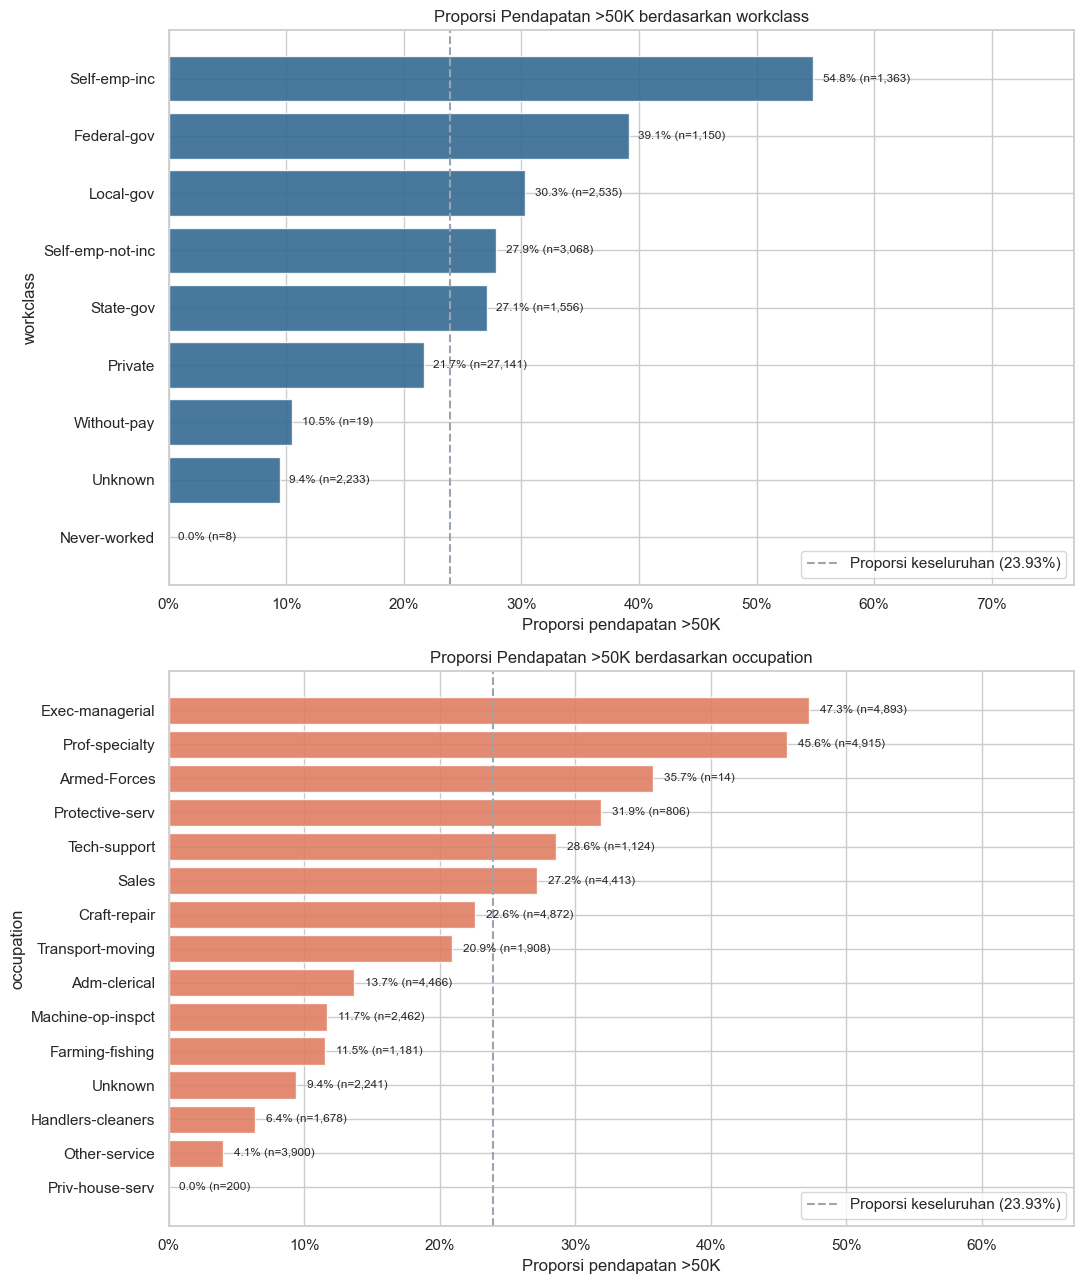

In [42]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 13),
)

plot_categorical_high_income_rate(
    categorical_summaries["workclass"],
    feature="workclass",
    ax=axes[0],
    color=COLOR_LOW_INCOME,
)

plot_categorical_high_income_rate(
    categorical_summaries["occupation"],
    feature="occupation",
    ax=axes[1],
    color=COLOR_HIGH_INCOME,
)

plt.tight_layout()
plt.show()

In [43]:
selected_categorical_features = [
    "education",
    "marital-status",
    "relationship",
]


for feature in selected_categorical_features:
    print(f"\nRingkasan fitur {feature}:")

    display(
        categorical_summaries[feature]
        .style
        .format({
            "jumlah": "{:,.0f}",
            "persentase_data": "{:.2%}",
            "jumlah_diatas_50K": "{:,.0f}",
            "proporsi_diatas_50K": "{:.2%}",
        })
    )


Ringkasan fitur education:


,jumlah,persentase_data,jumlah_diatas_50K,proporsi_diatas_50K
education,,,,
Prof-school,654,1.67%,490,74.92%
Doctorate,468,1.20%,349,74.57%
Masters,"2,131",5.45%,"1,173",55.04%
Bachelors,"6,379",16.33%,"2,638",41.35%
Assoc-acdm,"1,303",3.33%,339,26.02%
Assoc-voc,"1,657",4.24%,409,24.68%
Some-college,"8,739",22.37%,"1,677",19.19%
HS-grad,"12,582",32.20%,"1,990",15.82%
12th,532,1.36%,38,7.14%



Ringkasan fitur marital-status:


,jumlah,persentase_data,jumlah_diatas_50K,proporsi_diatas_50K
marital-status,,,,
Married-civ-spouse,"17,951",45.94%,"7,981",44.46%
Married-AF-spouse,28,0.07%,11,39.29%
Divorced,"5,298",13.56%,548,10.34%
Widowed,"1,226",3.14%,106,8.65%
Married-spouse-absent,502,1.28%,43,8.57%
Separated,"1,233",3.16%,74,6.00%
Never-married,"12,835",32.85%,586,4.57%



Ringkasan fitur relationship:


,jumlah,persentase_data,jumlah_diatas_50K,proporsi_diatas_50K
relationship,,,,
Wife,"1,852",4.74%,875,47.25%
Husband,"15,822",40.49%,"7,071",44.69%
Not-in-family,"10,061",25.75%,"1,029",10.23%
Unmarried,"4,087",10.46%,245,5.99%
Other-relative,"1,218",3.12%,40,3.28%
Own-child,"6,033",15.44%,89,1.48%


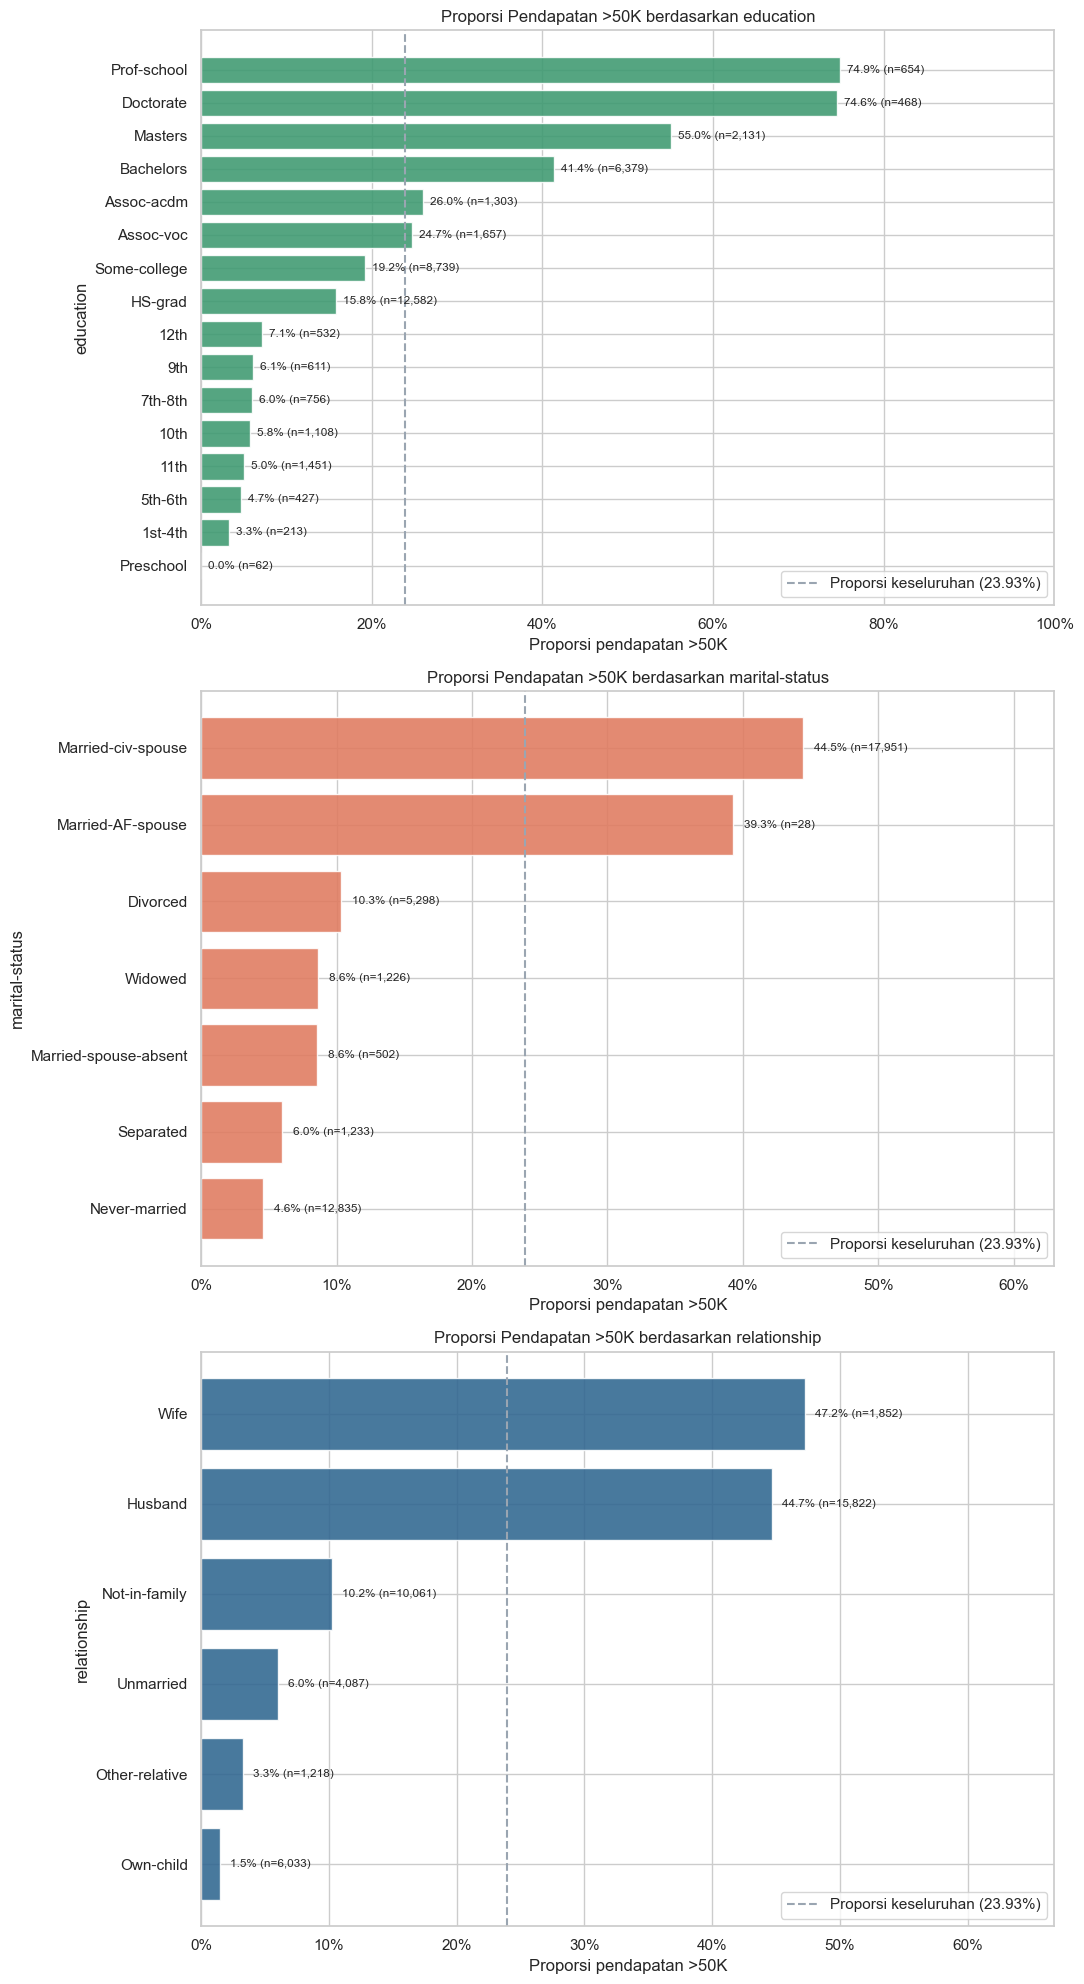

In [44]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(11, 20),
)


plot_categorical_high_income_rate(
    categorical_summaries["education"],
    feature="education",
    ax=axes[0],
    color=COLOR_ACCENT,
)


plot_categorical_high_income_rate(
    categorical_summaries["marital-status"],
    feature="marital-status",
    ax=axes[1],
    color=COLOR_HIGH_INCOME,
)


plot_categorical_high_income_rate(
    categorical_summaries["relationship"],
    feature="relationship",
    ax=axes[2],
    color=COLOR_LOW_INCOME,
)


plt.tight_layout()
plt.show()

In [45]:
key_categorical_records = []


for feature in selected_categorical_features:
    summary = categorical_summaries[feature]

    highest_category = summary.index[0]
    highest_row = summary.iloc[0]

    lowest_category = summary.index[-1]
    lowest_row = summary.iloc[-1]

    key_categorical_records.append({
        "fitur": feature,
        "kategori_tertinggi": highest_category,
        "jumlah_kategori_tertinggi": int(
            highest_row["jumlah"]
        ),
        "proporsi_tertinggi": (
            highest_row["proporsi_diatas_50K"]
        ),
        "kategori_terendah": lowest_category,
        "jumlah_kategori_terendah": int(
            lowest_row["jumlah"]
        ),
        "proporsi_terendah": (
            lowest_row["proporsi_diatas_50K"]
        ),
    })


key_categorical_findings = pd.DataFrame(
    key_categorical_records
)


display(
    key_categorical_findings
    .style
    .format({
        "jumlah_kategori_tertinggi": "{:,.0f}",
        "proporsi_tertinggi": "{:.2%}",
        "jumlah_kategori_terendah": "{:,.0f}",
        "proporsi_terendah": "{:.2%}",
    })
)

,fitur,kategori_tertinggi,jumlah_kategori_tertinggi,proporsi_tertinggi,kategori_terendah,jumlah_kategori_terendah,proporsi_terendah
0,education,Prof-school,654,74.92%,Preschool,62,0.00%
1,marital-status,Married-civ-spouse,"17,951",44.46%,Never-married,"12,835",4.57%
2,relationship,Wife,"1,852",47.25%,Own-child,"6,033",1.48%


In [46]:
sensitive_features = [
    "sex",
    "race",
]


for feature in sensitive_features:
    print(f"\nRingkasan fitur {feature}:")

    display(
        categorical_summaries[feature]
        .style
        .format({
            "jumlah": "{:,.0f}",
            "persentase_data": "{:.2%}",
            "jumlah_diatas_50K": "{:,.0f}",
            "proporsi_diatas_50K": "{:.2%}",
        })
    )


Ringkasan fitur sex:


,jumlah,persentase_data,jumlah_diatas_50K,proporsi_diatas_50K
sex,,,,
Male,"26,170",66.98%,"7,947",30.37%
Female,"12,903",33.02%,"1,402",10.87%



Ringkasan fitur race:


,jumlah,persentase_data,jumlah_diatas_50K,proporsi_diatas_50K
race,,,,
Asian-Pac-Islander,"1,215",3.11%,331,27.24%
White,"33,414",85.52%,"8,488",25.40%
Amer-Indian-Eskimo,366,0.94%,46,12.57%
Black,"3,741",9.57%,445,11.90%
Other,337,0.86%,39,11.57%


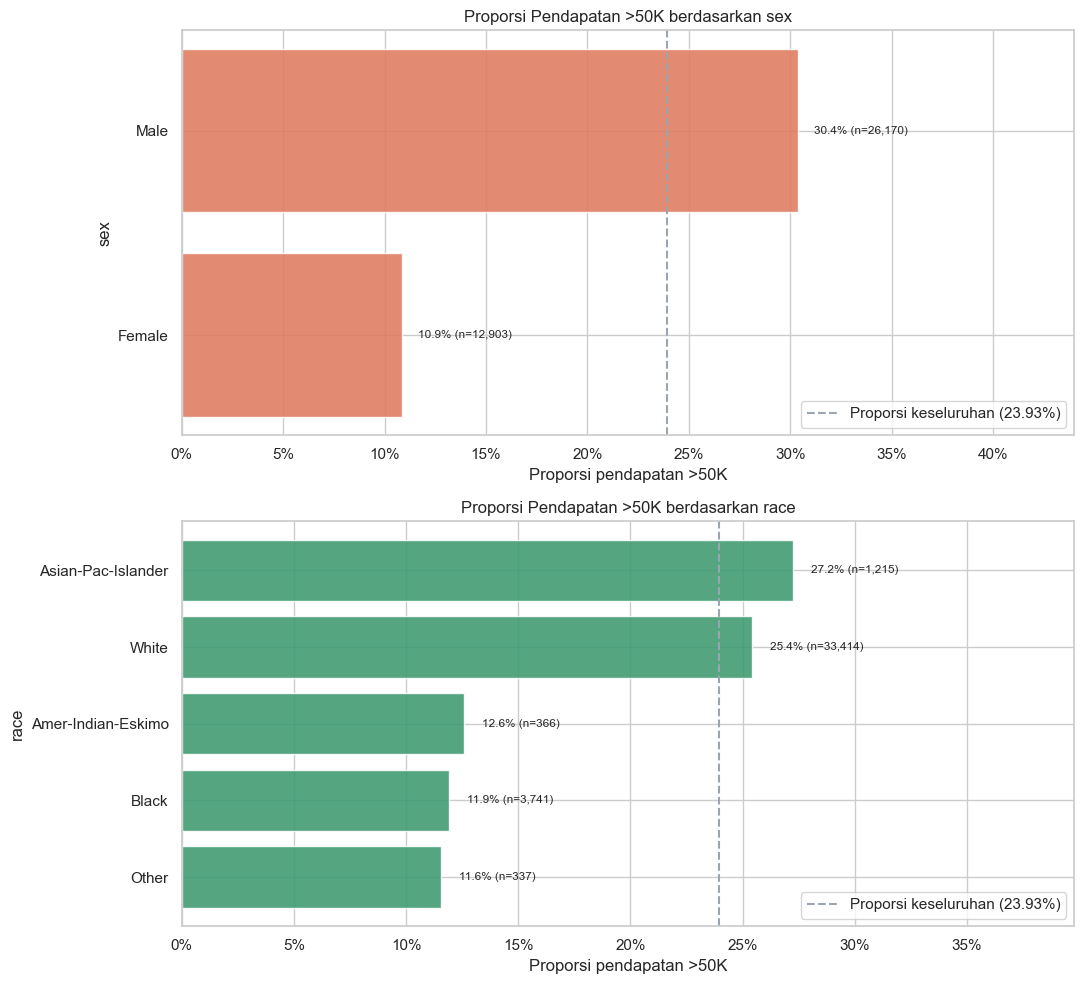

In [47]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 10),
)


plot_categorical_high_income_rate(
    categorical_summaries["sex"],
    feature="sex",
    ax=axes[0],
    color=COLOR_HIGH_INCOME,
)


plot_categorical_high_income_rate(
    categorical_summaries["race"],
    feature="race",
    ax=axes[1],
    color=COLOR_ACCENT,
)


plt.tight_layout()
plt.show()

In [48]:
native_country_summary = (
    categorical_summaries["native-country"]
    .copy()
)


native_country_by_count = (
    native_country_summary
    .sort_values(
        "jumlah",
        ascending=False,
    )
)


print(
    "Jumlah kategori native-country:",
    len(native_country_summary),
)


print("\nDua belas negara dengan jumlah data terbesar:")

display(
    native_country_by_count
    .head(12)
    .style
    .format({
        "jumlah": "{:,.0f}",
        "persentase_data": "{:.2%}",
        "jumlah_diatas_50K": "{:,.0f}",
        "proporsi_diatas_50K": "{:.2%}",
    })
)


assert (
    native_country_summary["jumlah"].sum()
    == len(eda_categorical)
)

Jumlah kategori native-country: 42

Dua belas negara dengan jumlah data terbesar:


,jumlah,persentase_data,jumlah_diatas_50K,proporsi_diatas_50K
native-country,,,,
United-States,"35,059",89.73%,"8,565",24.43%
Mexico,790,2.02%,42,5.32%
Unknown,688,1.76%,177,25.73%
Philippines,231,0.59%,72,31.17%
Germany,159,0.41%,46,28.93%
Puerto-Rico,143,0.37%,16,11.19%
Canada,142,0.36%,48,33.80%
El-Salvador,124,0.32%,7,5.65%
India,120,0.31%,46,38.33%


In [49]:
MIN_COUNTRY_COUNT = 100


common_country_mask = (
    native_country_summary["jumlah"]
    >= MIN_COUNTRY_COUNT
)


common_country_summary = (
    native_country_summary[
        common_country_mask
    ]
    .sort_values(
        "proporsi_diatas_50K",
        ascending=False,
    )
)


rare_country_summary = (
    native_country_summary[
        ~common_country_mask
    ]
)


country_support_summary = pd.DataFrame({
    "kelompok": [
        "Jumlah kategori >= 100",
        "Jumlah kategori < 100",
    ],
    "jumlah_kategori": [
        int(common_country_mask.sum()),
        int((~common_country_mask).sum()),
    ],
    "jumlah_baris": [
        int(
            common_country_summary["jumlah"]
            .sum()
        ),
        int(
            rare_country_summary["jumlah"]
            .sum()
        ),
    ],
})


country_support_summary["persentase_data"] = (
    country_support_summary["jumlah_baris"]
    / len(eda_categorical)
)


display(
    country_support_summary
    .style
    .format({
        "jumlah_kategori": "{:,.0f}",
        "jumlah_baris": "{:,.0f}",
        "persentase_data": "{:.2%}",
    })
)


assert (
    country_support_summary["jumlah_baris"]
    .sum()
    == len(eda_categorical)
)

,kelompok,jumlah_kategori,jumlah_baris,persentase_data
0,Jumlah kategori >= 100,10,"37,569",96.15%
1,Jumlah kategori < 100,32,"1,504",3.85%


In [50]:
print(
    "Native-country dengan minimal",
    MIN_COUNTRY_COUNT,
    "observasi:",
)


display(
    common_country_summary
    .style
    .format({
        "jumlah": "{:,.0f}",
        "persentase_data": "{:.2%}",
        "jumlah_diatas_50K": "{:,.0f}",
        "proporsi_diatas_50K": "{:.2%}",
    })
)

Native-country dengan minimal 100 observasi:


,jumlah,persentase_data,jumlah_diatas_50K,proporsi_diatas_50K
native-country,,,,
India,120,0.31%,46,38.33%
Canada,142,0.36%,48,33.80%
Philippines,231,0.59%,72,31.17%
Germany,159,0.41%,46,28.93%
Unknown,688,1.76%,177,25.73%
United-States,"35,059",89.73%,"8,565",24.43%
Cuba,113,0.29%,27,23.89%
Puerto-Rico,143,0.37%,16,11.19%
El-Salvador,124,0.32%,7,5.65%


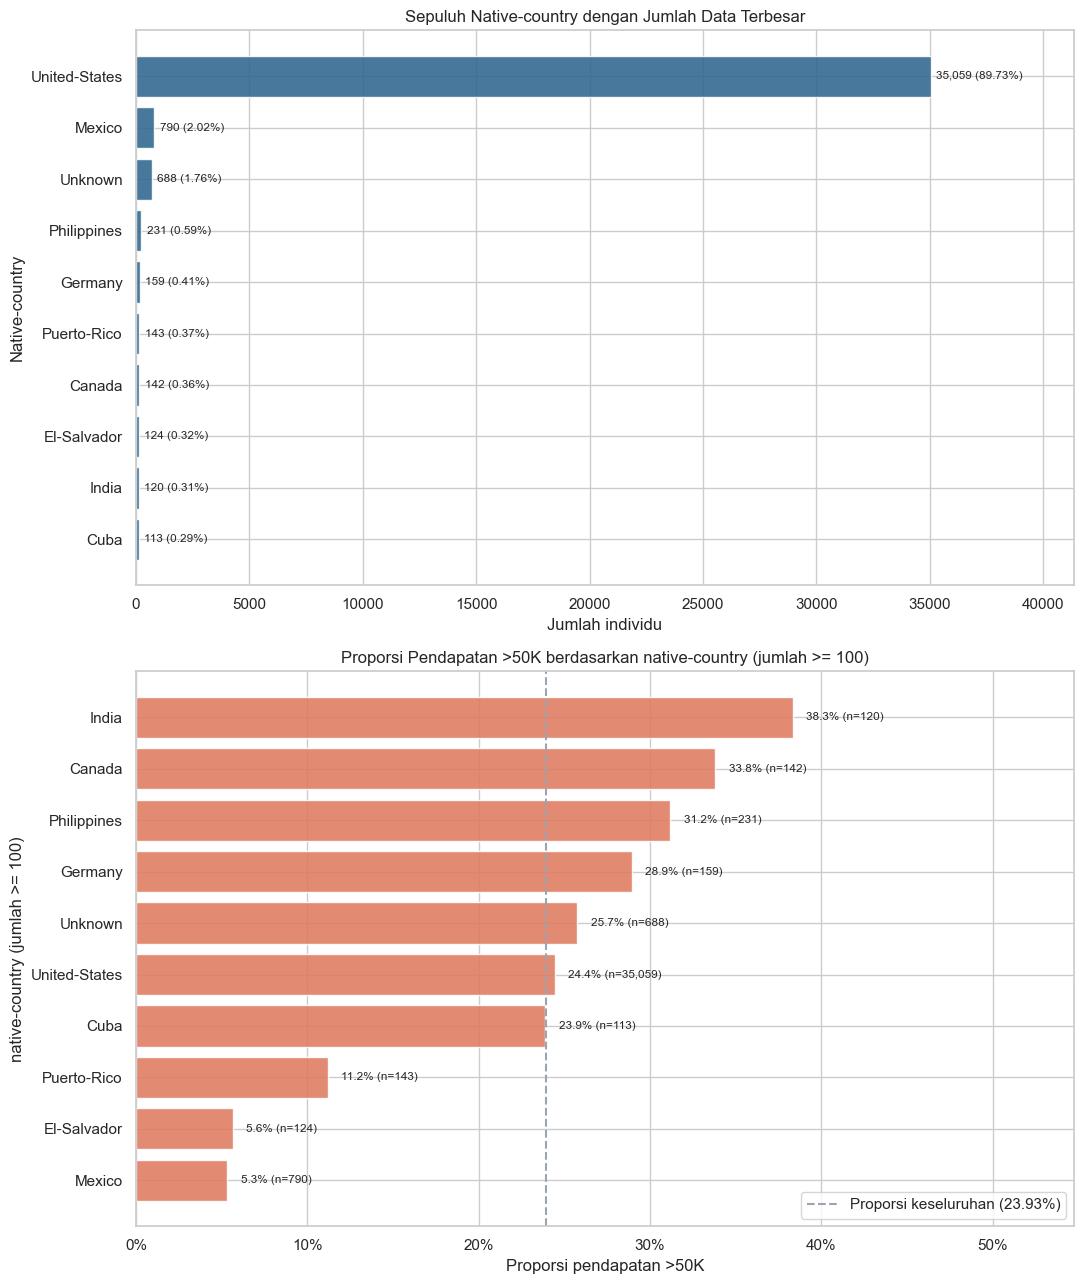

In [51]:
top_country_count = (
    native_country_by_count
    .head(10)
    .sort_values(
        "jumlah",
        ascending=True,
    )
)


fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 13),
)


# Grafik jumlah observasi
count_bars = axes[0].barh(
    top_country_count.index.astype(str),
    top_country_count["jumlah"],
    color=COLOR_LOW_INCOME,
    alpha=0.88,
)


axes[0].bar_label(
    count_bars,
    labels=[
        (
            f"{int(row['jumlah']):,} "
            f"({row['persentase_data']:.2%})"
        )
        for _, row
        in top_country_count.iterrows()
    ],
    padding=4,
    fontsize=8.5,
)


axes[0].set_xlim(
    0,
    top_country_count["jumlah"].max() * 1.18,
)

axes[0].set_title(
    "Sepuluh Native-country dengan Jumlah Data Terbesar"
)
axes[0].set_xlabel("Jumlah individu")
axes[0].set_ylabel("Native-country")


# Grafik proporsi >50K untuk kategori dengan n >= 100
plot_categorical_high_income_rate(
    common_country_summary,
    feature=(
        "native-country "
        f"(jumlah >= {MIN_COUNTRY_COUNT})"
    ),
    ax=axes[1],
    color=COLOR_HIGH_INCOME,
)


plt.tight_layout()
plt.show()

In [52]:
def normalize_target(series):
    """
    Mengubah label income menjadi target biner.

    <=50K -> 0
    >50K  -> 1
    """
    normalized = (
        series
        .astype("string")
        .str.strip()
        .str.rstrip(".")
    )

    allowed_labels = {
        "<=50K",
        ">50K",
    }

    unexpected_labels = sorted(
        set(normalized.dropna().unique())
        - allowed_labels
    )

    if unexpected_labels:
        raise ValueError(
            "Label target tidak dikenal: "
            f"{unexpected_labels}"
        )

    if normalized.isna().any():
        raise ValueError(
            "Target mengandung nilai kosong."
        )

    return (
        normalized
        .map({
            "<=50K": 0,
            ">50K": 1,
        })
        .astype(int)
    )


# Memastikan hasil fungsi sama dengan y dari Step 2
y_from_function = normalize_target(
    train_raw["income"]
)

assert np.array_equal(
    y_from_function.to_numpy(),
    y.to_numpy(),
)

# Menggunakan hasil fungsi reusable untuk tahap modeling
y = y_from_function

target_labels = y.map({
    0: "<=50K",
    1: ">50K",
})


print("Normalisasi target berhasil.")
print(target_labels.value_counts())

Normalisasi target berhasil.
income
<=50K    29724
>50K      9349
Name: count, dtype: int64


In [53]:
RAW_FEATURE_COLUMNS = [
    column
    for column in train_raw.columns
    if column != "income"
]


MODEL_CATEGORICAL_COLUMNS = (
    categorical_feature_columns.copy()
)


DERIVED_FEATURE_COLUMNS = [
    "capital-balance",
    "has-capital-gain",
    "has-capital-loss",
    "is-married",
    "is-us",
]


def clean_and_engineer_features(data):
    """
    Membersihkan fitur kategorikal dan menambahkan
    lima fitur turunan.

    Fungsi tidak mengubah dataframe asli.
    """
    missing_columns = [
        column
        for column in RAW_FEATURE_COLUMNS
        if column not in data.columns
    ]

    if missing_columns:
        raise KeyError(
            "Kolom fitur berikut tidak ditemukan: "
            f"{missing_columns}"
        )

    # Memastikan susunan kolom konsisten
    output = (
        data
        .loc[:, RAW_FEATURE_COLUMNS]
        .copy()
    )

    # Membersihkan seluruh fitur kategorikal
    for column in MODEL_CATEGORICAL_COLUMNS:
        output[column] = (
            output[column]
            .astype("string")
            .str.strip()
            .replace({
                "?": pd.NA,
                "": pd.NA,
            })
            .fillna("Unknown")
            # Object digunakan agar kompatibel dengan
            # encoder scikit-learn dan pandas 3.0.
            .astype("object")
        )

    # Feature engineering
    output["capital-balance"] = (
        output["capital-gain"]
        - output["capital-loss"]
    )

    output["has-capital-gain"] = (
        output["capital-gain"] > 0
    ).astype(int)

    output["has-capital-loss"] = (
        output["capital-loss"] > 0
    ).astype(int)

    output["is-married"] = (
        output["marital-status"]
        .str.startswith("Married")
    ).astype(int)

    output["is-us"] = (
        output["native-country"]
        == "United-States"
    ).astype(int)

    return output

In [54]:
X_raw = train_raw.drop(
    columns="income"
)

X = clean_and_engineer_features(
    X_raw
)


print(
    "Ukuran fitur sebelum engineering:",
    X_raw.shape,
)

print(
    "Ukuran fitur setelah engineering:",
    X.shape,
)

print(
    "Jumlah nilai kosong setelah preprocessing:",
    int(X.isna().sum().sum()),
)


display(
    X[
        [
            "capital-gain",
            "capital-loss",
            "capital-balance",
            "has-capital-gain",
            "has-capital-loss",
            "marital-status",
            "is-married",
            "native-country",
            "is-us",
        ]
    ]
    .head()
)

Ukuran fitur sebelum engineering: (39073, 14)
Ukuran fitur setelah engineering: (39073, 19)
Jumlah nilai kosong setelah preprocessing: 0


,capital-gain,capital-loss,capital-balance,has-capital-gain,has-capital-loss,marital-status,is-married,native-country,is-us
0,0,0,0,0,0,Never-married,0,United-States,1
1,0,1651,-1651,0,1,Married-civ-spouse,1,United-States,1
2,0,0,0,0,0,Separated,0,United-States,1
3,0,0,0,0,0,Widowed,0,United-States,1
4,0,0,0,0,0,Never-married,0,United-States,1


In [55]:
def feature_groups(data):
    """
    Memisahkan nama fitur kategorikal dan numerik.
    Kompatibel dengan dtype object maupun string.
    """
    categorical = [
        column
        for column in data.columns
        if (
            pd.api.types.is_string_dtype(
                data[column].dtype
            )
            or data[column].dtype == "object"
        )
    ]

    numeric = [
        column
        for column in data.columns
        if column not in categorical
    ]

    return categorical, numeric


model_categorical_columns, model_numeric_columns = (
    feature_groups(X)
)


feature_group_summary = pd.DataFrame({
    "kelompok_fitur": [
        "Kategorikal",
        "Numerik",
        "Total",
    ],
    "jumlah_kolom": [
        len(model_categorical_columns),
        len(model_numeric_columns),
        X.shape[1],
    ],
})


display(feature_group_summary)


print("Fitur kategorikal:")
for column in model_categorical_columns:
    print(f"- {column}")


print("\nFitur numerik:")
for column in model_numeric_columns:
    print(f"- {column}")


assert X.shape == (
    len(train_raw),
    19,
)

assert len(model_categorical_columns) == 8
assert len(model_numeric_columns) == 11
assert X.isna().sum().sum() == 0
assert X.index.equals(y.index)

assert X.columns.tolist() == (
    RAW_FEATURE_COLUMNS
    + DERIVED_FEATURE_COLUMNS
)

print(
    "\nSeluruh pemeriksaan feature engineering berhasil."
)

,kelompok_fitur,jumlah_kolom
0,Kategorikal,8
1,Numerik,11
2,Total,19


Fitur kategorikal:
- workclass
- education
- marital-status
- occupation
- relationship
- race
- sex
- native-country

Fitur numerik:
- age
- fnlwgt
- education-num
- capital-gain
- capital-loss
- hours-per-week
- capital-balance
- has-capital-gain
- has-capital-loss
- is-married
- is-us

Seluruh pemeriksaan feature engineering berhasil.


In [56]:
BINARY_DERIVED_COLUMNS = [
    "has-capital-gain",
    "has-capital-loss",
    "is-married",
    "is-us",
]


binary_derived_summary = pd.DataFrame({
    "jumlah_nilai_1": (
        X[BINARY_DERIVED_COLUMNS]
        .sum()
        .astype(int)
    ),
    "proporsi_nilai_1": (
        X[BINARY_DERIVED_COLUMNS]
        .mean()
    ),
})


display(
    binary_derived_summary
    .style
    .format({
        "jumlah_nilai_1": "{:,.0f}",
        "proporsi_nilai_1": "{:.2%}",
    })
)


capital_balance_summary = pd.DataFrame({
    "minimum": [
        X["capital-balance"].min()
    ],
    "maximum": [
        X["capital-balance"].max()
    ],
    "rata_rata": [
        X["capital-balance"].mean()
    ],
    "median": [
        X["capital-balance"].median()
    ],
})


display(
    capital_balance_summary
    .style
    .format({
        "minimum": "{:,.0f}",
        "maximum": "{:,.0f}",
        "rata_rata": "{:,.2f}",
        "median": "{:,.0f}",
    })
)


assert (
    X["capital-balance"]
    == (
        X["capital-gain"]
        - X["capital-loss"]
    )
).all()

assert all(
    set(X[column].unique()).issubset({0, 1})
    for column in BINARY_DERIVED_COLUMNS
)

print(
    "Seluruh fitur turunan berhasil diverifikasi."
)

,jumlah_nilai_1,proporsi_nilai_1
has-capital-gain,"3,190",8.16%
has-capital-loss,"1,814",4.64%
is-married,"18,481",47.30%
is-us,"35,059",89.73%


,minimum,maximum,rata_rata,median
0,"-4,356","99,999",951.23,0


Seluruh fitur turunan berhasil diverifikasi.


In [65]:
# Import untuk preprocessing, modeling, dan evaluasi
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    TargetEncoder,
)

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

print("Seluruh import preprocessing dan modeling berhasil.")

Seluruh import preprocessing dan modeling berhasil.


In [66]:
# Nama model dijaga tetap agar konsisten pada seluruh evaluasi
EXPECTED_MODEL_NAMES = [
    "Dummy baseline",
    "Logistic Regression",
    "Random Forest",
    "HistGradientBoosting (ordinal)",
    "HistGradientBoosting (target encoding)",
]


def make_models(data):
    """
    Membuat lima kandidat model beserta preprocessing-nya.

    Parameters
    ----------
    data : pandas.DataFrame
        Dataframe fitur hasil feature engineering.

    Returns
    -------
    dict
        Dictionary berisi nama dan estimator untuk setiap model.
    """

    categorical_columns, numeric_columns = feature_groups(data)

    # One-hot encoding dan standardisasi khusus Logistic Regression
    one_hot_scaled = ColumnTransformer([
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=2,
            ),
            categorical_columns,
        ),
        (
            "num",
            StandardScaler(),
            numeric_columns,
        ),
    ])

    # One-hot encoding tanpa scaling untuk Random Forest
    one_hot_tree = ColumnTransformer([
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=2,
            ),
            categorical_columns,
        ),
        (
            "num",
            "passthrough",
            numeric_columns,
        ),
    ])

    # Ordinal encoding untuk HistGradientBoosting
    ordinal = ColumnTransformer([
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            categorical_columns,
        ),
        (
            "num",
            "passthrough",
            numeric_columns,
        ),
    ])

    # Setelah ColumnTransformer:
    # kolom kategorikal berada di depan,
    # kemudian diikuti kolom numerik
    categorical_mask = (
        [True] * len(categorical_columns)
        + [False] * len(numeric_columns)
    )

    # Target encoding menggunakan internal cross-fitting
    target_encoded = ColumnTransformer([
        (
            "cat",
            TargetEncoder(
                target_type="binary",
                cv=5,
                shuffle=True,
                random_state=SEED,
            ),
            categorical_columns,
        ),
        (
            "num",
            "passthrough",
            numeric_columns,
        ),
    ])

    models = {
        "Dummy baseline": DummyClassifier(
            strategy="most_frequent",
        ),

        "Logistic Regression": Pipeline([
            (
                "preprocessor",
                one_hot_scaled,
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2500,
                    C=1.0,
                    random_state=SEED,
                ),
            ),
        ]),

        "Random Forest": Pipeline([
            (
                "preprocessor",
                one_hot_tree,
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=350,
                    min_samples_leaf=2,
                    max_features="sqrt",
                    n_jobs=-1,
                    random_state=SEED,
                ),
            ),
        ]),

        "HistGradientBoosting (ordinal)": Pipeline([
            (
                "preprocessor",
                ordinal,
            ),
            (
                "model",
                HistGradientBoostingClassifier(
                    learning_rate=0.05,
                    max_iter=600,
                    max_leaf_nodes=31,
                    min_samples_leaf=20,
                    l2_regularization=1.0,
                    categorical_features=categorical_mask,
                    early_stopping=True,
                    random_state=SEED,
                ),
            ),
        ]),

        "HistGradientBoosting (target encoding)": Pipeline([
            (
                "preprocessor",
                target_encoded,
            ),
            (
                "model",
                HistGradientBoostingClassifier(
                    learning_rate=0.05,
                    max_iter=600,
                    max_leaf_nodes=31,
                    min_samples_leaf=20,
                    l2_regularization=1.0,
                    early_stopping=True,
                    random_state=SEED,
                ),
            ),
        ]),
    }

    return models

In [67]:
def probability_high(model, data):
    """
    Mengambil probabilitas untuk kelas positif:
    1 = pendapatan >50K.
    """

    probabilities = model.predict_proba(data)

    # Mencari posisi kelas 1 agar tidak bergantung
    # pada asumsi urutan kolom predict_proba
    high_income_index = list(model.classes_).index(1)

    return probabilities[:, high_income_index]

In [68]:
def best_threshold(y_true, probability):
    """
    Mencari threshold yang menghasilkan F1-macro terbaik.

    Pencarian dilakukan dari 0.20 sampai 0.70
    dengan interval 0.002.
    """

    thresholds = np.round(
        np.arange(
            0.20,
            0.701,
            0.002,
        ),
        3,
    )

    scores = np.array([
        f1_score(
            y_true,
            probability >= threshold,
            average="macro",
        )
        for threshold in thresholds
    ])

    best_index = int(np.argmax(scores))

    return (
        float(thresholds[best_index]),
        float(scores[best_index]),
        thresholds,
        scores,
    )

In [69]:
# Membuat objek kandidat model
models = make_models(X)

# Memastikan kelompok fitur tetap konsisten
categorical_columns, numeric_columns = feature_groups(X)

print(
    "Jumlah model kandidat :",
    len(models),
)

print("\nDaftar kandidat model:")

for number, model_name in enumerate(
    models.keys(),
    start=1,
):
    estimator = models[model_name]

    print(
        f"{number}. {model_name}"
        f" [{estimator.__class__.__name__}]"
    )

Jumlah model kandidat : 5

Daftar kandidat model:
1. Dummy baseline [DummyClassifier]
2. Logistic Regression [Pipeline]
3. Random Forest [Pipeline]
4. HistGradientBoosting (ordinal) [Pipeline]
5. HistGradientBoosting (target encoding) [Pipeline]


In [70]:
model_configuration = pd.DataFrame([
    {
        "model": "Dummy baseline",
        "preprocessing_kategorikal": "Tidak diperlukan",
        "preprocessing_numerik": "Tidak diperlukan",
        "tujuan": "Baseline kelas mayoritas",
    },
    {
        "model": "Logistic Regression",
        "preprocessing_kategorikal": (
            "OneHotEncoder, min_frequency=2"
        ),
        "preprocessing_numerik": "StandardScaler",
        "tujuan": "Baseline linear",
    },
    {
        "model": "Random Forest",
        "preprocessing_kategorikal": (
            "OneHotEncoder, min_frequency=2"
        ),
        "preprocessing_numerik": "Passthrough",
        "tujuan": "Bagging non-linear",
    },
    {
        "model": "HistGradientBoosting (ordinal)",
        "preprocessing_kategorikal": (
            "OrdinalEncoder + categorical mask"
        ),
        "preprocessing_numerik": "Passthrough",
        "tujuan": "Boosting dengan kategori native",
    },
    {
        "model": "HistGradientBoosting (target encoding)",
        "preprocessing_kategorikal": (
            "TargetEncoder dengan cross-fitting"
        ),
        "preprocessing_numerik": "Passthrough",
        "tujuan": "Boosting dengan target encoding",
    },
]).set_index("model")

display(model_configuration)

,preprocessing_kategorikal,preprocessing_numerik,tujuan
model,,,
Dummy baseline,Tidak diperlukan,Tidak diperlukan,Baseline kelas mayoritas
Logistic Regression,"OneHotEncoder, min_frequency=2",StandardScaler,Baseline linear
Random Forest,"OneHotEncoder, min_frequency=2",Passthrough,Bagging non-linear
HistGradientBoosting (ordinal),OrdinalEncoder + categorical mask,Passthrough,Boosting dengan kategori native
HistGradientBoosting (target encoding),TargetEncoder dengan cross-fitting,Passthrough,Boosting dengan target encoding


In [72]:
# Mengambil categorical mask dari model HGB ordinal
ordinal_categorical_mask = np.asarray(
    models["HistGradientBoosting (ordinal)"]
    .named_steps["model"]
    .get_params()["categorical_features"],
    dtype=bool,
)

# Memeriksa grid threshold yang akan digunakan
threshold_grid_check = np.round(
    np.arange(
        0.20,
        0.701,
        0.002,
    ),
    3,
)

configuration_summary = pd.DataFrame({
    "pemeriksaan": [
        "Jumlah kandidat model",
        "Jumlah fitur kategorikal",
        "Jumlah fitur numerik",
        "Jumlah seluruh fitur",
        "Jumlah True pada categorical mask",
        "Jumlah kandidat threshold",
        "Threshold minimum",
        "Threshold maksimum",
        "Jumlah fold cross-validation",
        "Random seed",
    ],
    "hasil": [
        len(models),
        len(categorical_columns),
        len(numeric_columns),
        X.shape[1],
        int(ordinal_categorical_mask.sum()),
        len(threshold_grid_check),
        threshold_grid_check.min(),
        threshold_grid_check.max(),
        N_SPLITS,
        SEED,
    ],
})

display(configuration_summary)

# Memeriksa nama dan jumlah model
assert list(models.keys()) == EXPECTED_MODEL_NAMES
assert model_configuration.index.tolist() == EXPECTED_MODEL_NAMES
assert len(models) == 5

# Memeriksa kelompok fitur
assert len(categorical_columns) == 8
assert len(numeric_columns) == 11
assert X.shape[1] == 19

assert set(categorical_columns).isdisjoint(
    numeric_columns
)

assert set(
    categorical_columns + numeric_columns
) == set(X.columns)

# Memeriksa categorical mask
assert len(ordinal_categorical_mask) == X.shape[1]

assert ordinal_categorical_mask[
    :len(categorical_columns)
].all()

assert not ordinal_categorical_mask[
    len(categorical_columns):
].any()

# Memeriksa grid threshold
assert len(threshold_grid_check) == 251
assert threshold_grid_check[0] == 0.20
assert threshold_grid_check[-1] == 0.70

# Memeriksa konfigurasi reproduktibilitas
assert N_SPLITS == 5
assert SEED == 42

print(
    "\nSeluruh konfigurasi preprocessing "
    "dan model berhasil diverifikasi."
)

,pemeriksaan,hasil
0,Jumlah kandidat model,5.0000
1,Jumlah fitur kategorikal,8.0000
2,Jumlah fitur numerik,11.0000
3,Jumlah seluruh fitur,19.0000
4,Jumlah True pada categorical mask,8.0000
5,Jumlah kandidat threshold,251.0000
6,Threshold minimum,0.2000
7,Threshold maksimum,0.7000
8,Jumlah fold cross-validation,5.0000
9,Random seed,42.0000



Seluruh konfigurasi preprocessing dan model berhasil diverifikasi.


In [73]:
# Membuat ulang template model dalam kondisi belum dilatih
models = make_models(X)

# Stratified K-Fold menjaga distribusi kelas pada setiap fold
splitter = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED,
)

# Menampung probabilitas OOF setiap model
oof_probabilities = {}

# Menampung hasil evaluasi setiap fold
fold_records = []

for model_name, model_template in models.items():
    print(f"\nMemvalidasi {model_name}...")

    # Tempat menyimpan probabilitas seluruh observasi
    oof = np.zeros(
        len(X),
        dtype=float,
    )

    # Memastikan setiap observasi mendapat prediksi OOF
    assigned_rows = np.zeros(
        len(X),
        dtype=bool,
    )

    for fold, (train_idx, valid_idx) in enumerate(
        splitter.split(X, y),
        start=1,
    ):
        # Clone agar setiap fold menggunakan model baru
        fold_model = clone(model_template)

        X_train_fold = X.iloc[train_idx]
        X_valid_fold = X.iloc[valid_idx]

        y_train_fold = y.iloc[train_idx]
        y_valid_fold = y.iloc[valid_idx]

        # Melatih model hanya menggunakan data training fold
        fold_model.fit(
            X_train_fold,
            y_train_fold,
        )

        # Mengambil probabilitas kelas income >50K
        valid_probability = probability_high(
            fold_model,
            X_valid_fold,
        )

        # Menyimpan probabilitas sesuai indeks validasi
        oof[valid_idx] = valid_probability
        assigned_rows[valid_idx] = True

        # Prediksi kelas menggunakan threshold awal 0.50
        valid_prediction = (
            valid_probability >= 0.50
        ).astype("int8")

        fold_f1_macro = f1_score(
            y_valid_fold,
            valid_prediction,
            average="macro",
            zero_division=0,
        )

        fold_records.append({
            "model": model_name,
            "fold": fold,
            "jumlah_train": len(train_idx),
            "jumlah_validasi": len(valid_idx),
            "f1_macro_at_0.5": fold_f1_macro,
        })

        print(
            f"  Fold {fold}/{N_SPLITS} selesai "
            f"| F1-macro: {fold_f1_macro:.4f}"
        )

    # Pemeriksaan probabilitas OOF
    assert assigned_rows.all()
    assert np.isfinite(oof).all()
    assert ((oof >= 0) & (oof <= 1)).all()

    oof_probabilities[model_name] = oof

    print(f"{model_name} selesai divalidasi.")

print("\nSeluruh kandidat model selesai divalidasi.")


Memvalidasi Dummy baseline...
  Fold 1/5 selesai | F1-macro: 0.4320
  Fold 2/5 selesai | F1-macro: 0.4320
  Fold 3/5 selesai | F1-macro: 0.4320
  Fold 4/5 selesai | F1-macro: 0.4321
  Fold 5/5 selesai | F1-macro: 0.4320
Dummy baseline selesai divalidasi.

Memvalidasi Logistic Regression...
  Fold 1/5 selesai | F1-macro: 0.7859
  Fold 2/5 selesai | F1-macro: 0.7849
  Fold 3/5 selesai | F1-macro: 0.7926
  Fold 4/5 selesai | F1-macro: 0.7832
  Fold 5/5 selesai | F1-macro: 0.7825
Logistic Regression selesai divalidasi.

Memvalidasi Random Forest...
  Fold 1/5 selesai | F1-macro: 0.7998
  Fold 2/5 selesai | F1-macro: 0.7982
  Fold 3/5 selesai | F1-macro: 0.8025
  Fold 4/5 selesai | F1-macro: 0.7935
  Fold 5/5 selesai | F1-macro: 0.7956
Random Forest selesai divalidasi.

Memvalidasi HistGradientBoosting (ordinal)...
  Fold 1/5 selesai | F1-macro: 0.8189
  Fold 2/5 selesai | F1-macro: 0.8128
  Fold 3/5 selesai | F1-macro: 0.8172
  Fold 4/5 selesai | F1-macro: 0.8150
  Fold 5/5 selesai | F1-m

In [74]:
fold_results = pd.DataFrame(fold_records)

fold_summary = (
    fold_results
    .groupby("model")["f1_macro_at_0.5"]
    .agg([
        "mean",
        "std",
        "min",
        "max",
    ])
    .reindex(EXPECTED_MODEL_NAMES)
    .rename(columns={
        "mean": "rata_rata",
        "std": "standar_deviasi",
        "min": "minimum",
        "max": "maksimum",
    })
)

display(fold_results)
display(fold_summary)

# Memastikan jumlah hasil sesuai:
# 5 model × 5 fold = 25 baris
assert len(fold_results) == (
    len(models) * N_SPLITS
)

assert fold_results["model"].nunique() == 5
assert fold_results["fold"].nunique() == N_SPLITS

assert list(oof_probabilities.keys()) == (
    EXPECTED_MODEL_NAMES
)

assert all(
    len(probability) == len(X)
    for probability in oof_probabilities.values()
)

print(
    "\nPrediksi OOF untuk seluruh model "
    "berhasil dibuat dan diverifikasi."
)

,model,fold,jumlah_train,jumlah_validasi,f1_macro_at_0.5
0,Dummy baseline,1,31258,7815,0.4320
1,Dummy baseline,2,31258,7815,0.4320
2,Dummy baseline,3,31258,7815,0.4320
3,Dummy baseline,4,31259,7814,0.4321
4,Dummy baseline,5,31259,7814,0.4320
5,Logistic Regression,1,31258,7815,0.7859
6,Logistic Regression,2,31258,7815,0.7849
7,Logistic Regression,3,31258,7815,0.7926
8,Logistic Regression,4,31259,7814,0.7832
9,Logistic Regression,5,31259,7814,0.7825


,rata_rata,standar_deviasi,minimum,maksimum
model,,,,
Dummy baseline,0.4321,0.0000,0.4320,0.4321
Logistic Regression,0.7858,0.0040,0.7825,0.7926
Random Forest,0.7979,0.0035,0.7935,0.8025
HistGradientBoosting (ordinal),0.8150,0.0032,0.8111,0.8189
HistGradientBoosting (target encoding),0.8137,0.0032,0.8094,0.8169



Prediksi OOF untuk seluruh model berhasil dibuat dan diverifikasi.


In [75]:
# Nama model untuk menghindari kesalahan penulisan
HGB_ORDINAL_NAME = (
    "HistGradientBoosting (ordinal)"
)

HGB_TARGET_NAME = (
    "HistGradientBoosting (target encoding)"
)

RANDOM_FOREST_NAME = "Random Forest"

ENSEMBLE_HGB_NAME = "Ensemble HGB"

ENSEMBLE_HGB_RF_NAME = (
    "Ensemble HGB + RF"
)

# Memastikan probabilitas model dasar tersedia
required_oof_models = [
    HGB_ORDINAL_NAME,
    HGB_TARGET_NAME,
    RANDOM_FOREST_NAME,
]

assert all(
    model_name in oof_probabilities
    for model_name in required_oof_models
)

# Ensemble utama:
# 50% HGB ordinal + 50% HGB target encoding
oof_probabilities[ENSEMBLE_HGB_NAME] = (
    0.50
    * (
        oof_probabilities[HGB_ORDINAL_NAME]
        + oof_probabilities[HGB_TARGET_NAME]
    )
)

# Ensemble pembanding:
# 45% HGB ordinal + 35% HGB target encoding
# + 20% Random Forest
oof_probabilities[ENSEMBLE_HGB_RF_NAME] = (
    0.45
    * oof_probabilities[HGB_ORDINAL_NAME]
    + 0.35
    * oof_probabilities[HGB_TARGET_NAME]
    + 0.20
    * oof_probabilities[RANDOM_FOREST_NAME]
)

ensemble_configuration = pd.DataFrame([
    {
        "ensemble": ENSEMBLE_HGB_NAME,
        "HGB_ordinal": 0.50,
        "HGB_target_encoding": 0.50,
        "Random_Forest": 0.00,
        "jumlah_bobot": 1.00,
    },
    {
        "ensemble": ENSEMBLE_HGB_RF_NAME,
        "HGB_ordinal": 0.45,
        "HGB_target_encoding": 0.35,
        "Random_Forest": 0.20,
        "jumlah_bobot": 1.00,
    },
]).set_index("ensemble")

display(ensemble_configuration)

# Daftar lengkap model dan ensemble OOF
EXPECTED_OOF_NAMES = (
    EXPECTED_MODEL_NAMES
    + [
        ENSEMBLE_HGB_NAME,
        ENSEMBLE_HGB_RF_NAME,
    ]
)

assert list(
    oof_probabilities.keys()
) == EXPECTED_OOF_NAMES

# Memeriksa probabilitas kedua ensemble
for ensemble_name in [
    ENSEMBLE_HGB_NAME,
    ENSEMBLE_HGB_RF_NAME,
]:
    ensemble_probability = (
        oof_probabilities[ensemble_name]
    )

    assert len(ensemble_probability) == len(X)
    assert np.isfinite(ensemble_probability).all()

    assert (
        (ensemble_probability >= 0)
        & (ensemble_probability <= 1)
    ).all()

# Memastikan seluruh bobot berjumlah satu
assert np.allclose(
    ensemble_configuration["jumlah_bobot"],
    1.0,
)

print(
    "Dua ensemble OOF berhasil dibuat "
    "dan diverifikasi."
)

print(
    "Jumlah model dan ensemble yang "
    "akan dibandingkan:",
    len(oof_probabilities),
)

,HGB_ordinal,HGB_target_encoding,Random_Forest,jumlah_bobot
ensemble,,,,
Ensemble HGB,0.5000,0.5000,0.0000,1.0000
Ensemble HGB + RF,0.4500,0.3500,0.2000,1.0000


Dua ensemble OOF berhasil dibuat dan diverifikasi.
Jumlah model dan ensemble yang akan dibandingkan: 7


In [76]:
# Menampung hasil perbandingan model
comparison_rows = []

# Menyimpan kurva threshold untuk visualisasi berikutnya
threshold_curves = {}

for model_name, probability in (
    oof_probabilities.items()
):
    # Evaluasi menggunakan threshold standar 0.50
    prediction_at_05 = (
        probability >= 0.50
    ).astype("int8")

    f1_at_05 = f1_score(
        y,
        prediction_at_05,
        average="macro",
        zero_division=0,
    )

    # Mencari threshold terbaik berdasarkan F1-macro
    (
        optimal_threshold,
        optimal_f1,
        evaluated_thresholds,
        threshold_scores,
    ) = best_threshold(
        y,
        probability,
    )

    comparison_rows.append({
        "model": model_name,
        "f1_macro_at_0.5": f1_at_05,
        "best_threshold": optimal_threshold,
        "f1_macro_tuned": optimal_f1,
        "peningkatan_f1": (
            optimal_f1 - f1_at_05
        ),
        "roc_auc": roc_auc_score(
            y,
            probability,
        ),
    })

    threshold_curves[model_name] = (
        evaluated_thresholds,
        threshold_scores,
    )

comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        "f1_macro_tuned",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    comparison.round({
        "f1_macro_at_0.5": 4,
        "best_threshold": 3,
        "f1_macro_tuned": 4,
        "peningkatan_f1": 4,
        "roc_auc": 4,
    })
)

# Pemeriksaan hasil evaluasi
assert len(comparison) == 7

assert set(comparison["model"]) == set(
    EXPECTED_OOF_NAMES
)

assert comparison[
    "best_threshold"
].between(
    0.20,
    0.70,
).all()

assert (
    comparison["f1_macro_tuned"]
    >= comparison["f1_macro_at_0.5"]
).all()

assert comparison[
    "roc_auc"
].between(
    0,
    1,
).all()

print(
    "\nPerbandingan model dan optimasi "
    "threshold berhasil dilakukan."
)

,model,f1_macro_at_0.5,best_threshold,f1_macro_tuned,peningkatan_f1,roc_auc
0,Ensemble HGB,0.8149,0.4500,0.8199,0.0050,0.9283
1,HistGradientBoosting (target encoding),0.8138,0.4320,0.8198,0.0060,0.9275
2,Ensemble HGB + RF,0.8142,0.4220,0.8195,0.0053,0.9279
3,HistGradientBoosting (ordinal),0.8150,0.4060,0.8189,0.0039,0.9280
4,Random Forest,0.7979,0.4120,0.8115,0.0136,0.9190
5,Logistic Regression,0.7858,0.3960,0.7964,0.0106,0.9095
6,Dummy baseline,0.4321,0.2000,0.4321,0.0000,0.5000



Perbandingan model dan optimasi threshold berhasil dilakukan.


In [77]:
from sklearn.metrics import balanced_accuracy_score

print("Import balanced_accuracy_score berhasil.")

Import balanced_accuracy_score berhasil.


In [78]:
# Mengambil baris dengan F1-macro tuned tertinggi
selected_row = comparison.iloc[0]

selected_model = selected_row["model"]
selected_threshold = float(
    selected_row["best_threshold"]
)

# Mengambil probabilitas OOF model terpilih
selected_probability = (
    oof_probabilities[selected_model]
)

# Mengubah probabilitas menjadi prediksi kelas
selected_prediction = (
    selected_probability >= selected_threshold
).astype("int8")

print("Model terpilih     :", selected_model)
print(
    "Threshold terpilih :",
    f"{selected_threshold:.3f}",
)

# Pemeriksaan model yang diharapkan
assert selected_model == ENSEMBLE_HGB_NAME

assert np.isclose(
    selected_threshold,
    0.450,
)

assert len(selected_probability) == len(X)
assert len(selected_prediction) == len(y)

assert np.isfinite(
    selected_probability
).all()

assert set(
    np.unique(selected_prediction)
).issubset({0, 1})

print(
    "\nModel dan threshold terbaik "
    "berhasil dipilih."
)

Model terpilih     : Ensemble HGB
Threshold terpilih : 0.450

Model dan threshold terbaik berhasil dipilih.


In [79]:
# Menghitung metrik keseluruhan
selected_accuracy = accuracy_score(
    y,
    selected_prediction,
)

selected_balanced_accuracy = (
    balanced_accuracy_score(
        y,
        selected_prediction,
    )
)

selected_f1_macro = f1_score(
    y,
    selected_prediction,
    average="macro",
    zero_division=0,
)

selected_roc_auc = roc_auc_score(
    y,
    selected_probability,
)

# Metrik khusus kelas income >50K
selected_precision_high = precision_score(
    y,
    selected_prediction,
    pos_label=1,
    zero_division=0,
)

selected_recall_high = recall_score(
    y,
    selected_prediction,
    pos_label=1,
    zero_division=0,
)

selected_f1_high = f1_score(
    y,
    selected_prediction,
    pos_label=1,
    zero_division=0,
)

# Metrik khusus kelas income <=50K
selected_precision_low = precision_score(
    y,
    selected_prediction,
    pos_label=0,
    zero_division=0,
)

selected_recall_low = recall_score(
    y,
    selected_prediction,
    pos_label=0,
    zero_division=0,
)

selected_f1_low = f1_score(
    y,
    selected_prediction,
    pos_label=0,
    zero_division=0,
)

selected_metrics = pd.DataFrame([{
    "model": selected_model,
    "threshold": selected_threshold,
    "accuracy": selected_accuracy,
    "balanced_accuracy": (
        selected_balanced_accuracy
    ),
    "f1_macro": selected_f1_macro,
    "roc_auc": selected_roc_auc,
    "precision_<=50K": selected_precision_low,
    "recall_<=50K": selected_recall_low,
    "f1_<=50K": selected_f1_low,
    "precision_>50K": selected_precision_high,
    "recall_>50K": selected_recall_high,
    "f1_>50K": selected_f1_high,
}]).set_index("model")

display(
    selected_metrics.round(4)
)

# Classification report dalam bentuk tabel
report_dictionary = classification_report(
    y,
    selected_prediction,
    labels=[0, 1],
    target_names=["<=50K", ">50K"],
    output_dict=True,
    zero_division=0,
)

classification_report_table = (
    pd.DataFrame(report_dictionary)
    .T
)

display(
    classification_report_table.round(4)
)

# Memastikan hasil sama dengan tabel perbandingan
expected_selected_f1 = (
    comparison.loc[
        comparison["model"] == selected_model,
        "f1_macro_tuned",
    ]
    .iloc[0]
)

assert np.isclose(
    selected_f1_macro,
    expected_selected_f1,
)

assert 0 <= selected_accuracy <= 1
assert 0 <= selected_balanced_accuracy <= 1
assert 0 <= selected_f1_macro <= 1
assert 0 <= selected_roc_auc <= 1

print(
    "\nEvaluasi rinci model terpilih "
    "berhasil dilakukan."
)

,threshold,accuracy,balanced_accuracy,f1_macro,roc_auc,precision_<=50K,recall_<=50K,f1_<=50K,precision_>50K,recall_>50K,f1_>50K
model,,,,,,,,,,,
Ensemble HGB,0.4500,0.8714,0.8140,0.8199,0.9283,0.9085,0.9240,0.9162,0.7445,0.7040,0.7237


,precision,recall,f1-score,support
<=50K,0.9085,0.9240,0.9162,"29,724.0000"
>50K,0.7445,0.7040,0.7237,"9,349.0000"
accuracy,0.8714,0.8714,0.8714,0.8714
macro avg,0.8265,0.8140,0.8199,"39,073.0000"
weighted avg,0.8692,0.8714,0.8701,"39,073.0000"



Evaluasi rinci model terpilih berhasil dilakukan.


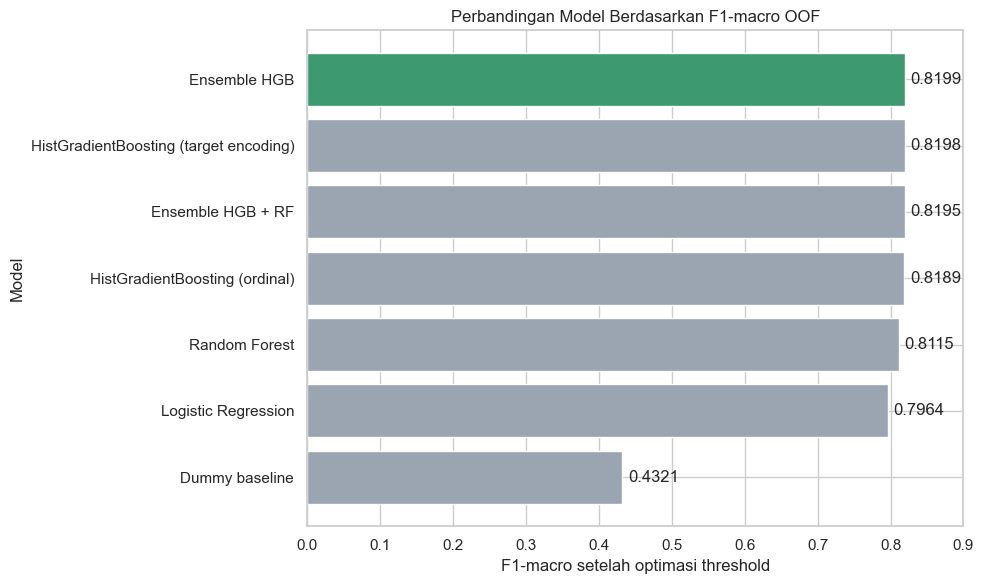

In [80]:
# Mengurutkan model dari nilai terendah
# ke nilai tertinggi
ordered_comparison = (
    comparison
    .sort_values("f1_macro_tuned")
    .copy()
)

bar_colors = [
    (
        COLOR_ACCENT
        if model_name == selected_model
        else COLOR_MUTED
    )
    for model_name in ordered_comparison["model"]
]

fig, ax = plt.subplots(
    figsize=(10, 6),
)

bars = ax.barh(
    ordered_comparison["model"],
    ordered_comparison["f1_macro_tuned"],
    color=bar_colors,
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in (
            ordered_comparison["f1_macro_tuned"]
        )
    ],
    padding=4,
)

ax.set_title(
    "Perbandingan Model Berdasarkan "
    "F1-macro OOF"
)

ax.set_xlabel(
    "F1-macro setelah optimasi threshold"
)

ax.set_ylabel("Model")
ax.set_xlim(0, 0.90)

plt.tight_layout()
plt.show()

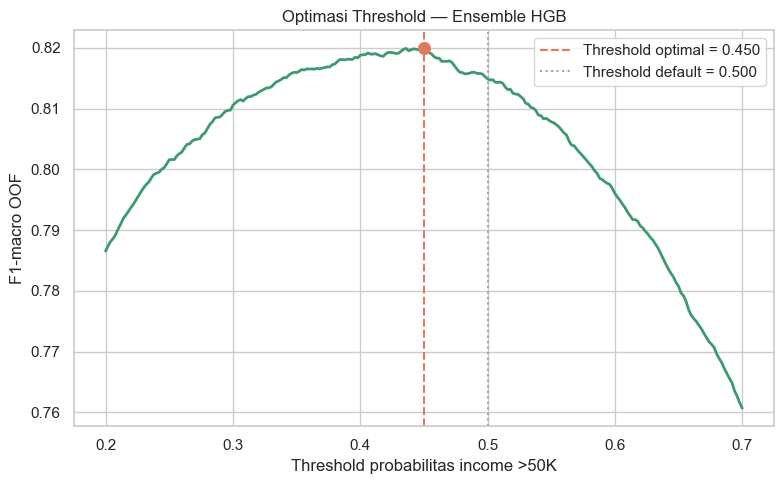

In [81]:
selected_thresholds, selected_scores = (
    threshold_curves[selected_model]
)

fig, ax = plt.subplots(
    figsize=(8, 5),
)

ax.plot(
    selected_thresholds,
    selected_scores,
    color=COLOR_ACCENT,
    linewidth=2,
)

# Threshold optimal
ax.axvline(
    selected_threshold,
    color=COLOR_HIGH_INCOME,
    linestyle="--",
    label=(
        "Threshold optimal = "
        f"{selected_threshold:.3f}"
    ),
)

# Threshold default
ax.axvline(
    0.50,
    color=COLOR_MUTED,
    linestyle=":",
    label="Threshold default = 0.500",
)

ax.scatter(
    [selected_threshold],
    [selected_f1_macro],
    color=COLOR_HIGH_INCOME,
    s=70,
    zorder=3,
)

ax.set_title(
    f"Optimasi Threshold — {selected_model}"
)

ax.set_xlabel(
    "Threshold probabilitas income >50K"
)

ax.set_ylabel("F1-macro OOF")
ax.legend()

plt.tight_layout()
plt.show()

,komponen,singkatan,aktual,prediksi,jumlah
0,True Negative,TN,<=50K,<=50K,27465
1,False Positive,FP,<=50K,>50K,2259
2,False Negative,FN,>50K,<=50K,2767
3,True Positive,TP,>50K,>50K,6582


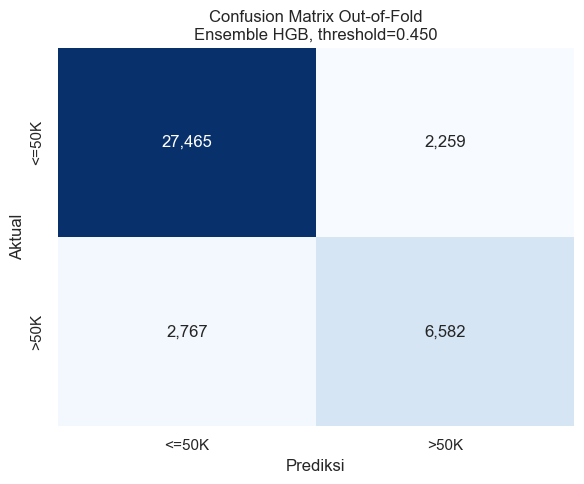


Confusion matrix model terpilih berhasil dibuat.


In [82]:
selected_confusion_matrix = confusion_matrix(
    y,
    selected_prediction,
    labels=[0, 1],
)

tn, fp, fn, tp = (
    selected_confusion_matrix.ravel()
)

confusion_summary = pd.DataFrame([
    {
        "komponen": "True Negative",
        "singkatan": "TN",
        "aktual": "<=50K",
        "prediksi": "<=50K",
        "jumlah": tn,
    },
    {
        "komponen": "False Positive",
        "singkatan": "FP",
        "aktual": "<=50K",
        "prediksi": ">50K",
        "jumlah": fp,
    },
    {
        "komponen": "False Negative",
        "singkatan": "FN",
        "aktual": ">50K",
        "prediksi": "<=50K",
        "jumlah": fn,
    },
    {
        "komponen": "True Positive",
        "singkatan": "TP",
        "aktual": ">50K",
        "prediksi": ">50K",
        "jumlah": tp,
    },
])

display(confusion_summary)

assert selected_confusion_matrix.shape == (2, 2)

assert (
    selected_confusion_matrix.sum()
    == len(y)
)

fig, ax = plt.subplots(
    figsize=(6, 5),
)

sns.heatmap(
    selected_confusion_matrix,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"],
    ax=ax,
)

ax.set_title(
    "Confusion Matrix Out-of-Fold\n"
    f"{selected_model}, "
    f"threshold={selected_threshold:.3f}"
)

ax.set_xlabel("Prediksi")
ax.set_ylabel("Aktual")

plt.tight_layout()
plt.show()

print(
    "\nConfusion matrix model terpilih "
    "berhasil dibuat."
)

In [83]:
# Membaca test.csv dan template submission
test_raw = pd.read_csv(TEST_PATH)

sample_submission = pd.read_csv(
    SAMPLE_SUBMISSION_PATH
)

# Menyimpan ID tanpa mengubah urutannya
test_ids = test_raw["id"].copy()

# Daftar fitur mentah pada train dan test
train_feature_columns = (
    train_raw
    .drop(columns="income")
    .columns
    .tolist()
)

test_feature_columns = (
    test_raw
    .drop(columns="id")
    .columns
    .tolist()
)

print("Ukuran test              :", test_raw.shape)
print(
    "Ukuran sample submission :",
    sample_submission.shape,
)

# Pemeriksaan struktur test
assert "id" in test_raw.columns
assert "income" not in test_raw.columns
assert test_ids.is_unique

assert test_feature_columns == (
    train_feature_columns
)

# Pemeriksaan template submission
assert sample_submission.columns.tolist() == [
    "id",
    "income",
]

assert len(sample_submission) == len(test_raw)

assert sample_submission["id"].equals(
    test_ids
)

print(
    "\nStruktur test dan sample submission "
    "berhasil diverifikasi."
)

Ukuran test              : (9769, 15)
Ukuran sample submission : (9769, 2)

Struktur test dan sample submission berhasil diverifikasi.


In [84]:
# Menghapus ID karena bukan fitur prediktor
test_features_raw = test_raw.drop(
    columns="id"
)

# Menggunakan fungsi yang sama dengan train
X_test = clean_and_engineer_features(
    test_features_raw
)

print(
    "Ukuran fitur test setelah "
    "feature engineering:",
    X_test.shape,
)

print(
    "Jumlah nilai kosong pada X_test:",
    int(X_test.isna().sum().sum()),
)

# Train dan test harus memiliki fitur
# dengan nama dan urutan yang sama
assert X_test.columns.tolist() == (
    X.columns.tolist()
)

assert X_test.shape[1] == X.shape[1]
assert len(X_test) == len(test_raw)

assert not X_test.isna().any().any()

print(
    "\nPreprocessing dan feature engineering "
    "test berhasil dilakukan."
)

Ukuran fitur test setelah feature engineering: (9769, 19)
Jumlah nilai kosong pada X_test: 0

Preprocessing dan feature engineering test berhasil dilakukan.


In [85]:
# Model final merupakan gabungan dua HGB
final_component_weights = {
    HGB_ORDINAL_NAME: 0.50,
    HGB_TARGET_NAME: 0.50,
}

component_configuration = pd.DataFrame([
    {
        "model": model_name,
        "bobot": weight,
    }
    for model_name, weight
    in final_component_weights.items()
]).set_index("model")

display(component_configuration)

assert selected_model == ENSEMBLE_HGB_NAME

assert set(
    final_component_weights
) == {
    HGB_ORDINAL_NAME,
    HGB_TARGET_NAME,
}

assert np.isclose(
    sum(final_component_weights.values()),
    1.0,
)

print(
    "Konfigurasi ensemble final "
    "berhasil diverifikasi."
)

,bobot
model,
HistGradientBoosting (ordinal),0.5000
HistGradientBoosting (target encoding),0.5000


Konfigurasi ensemble final berhasil diverifikasi.


In [86]:
# Membuat template model baru yang belum dilatih
final_model_templates = make_models(X)

# Menampung model yang sudah dilatih
fitted_components = {}

# Menampung probabilitas ensemble pada test
test_probability = np.zeros(
    len(X_test),
    dtype=float,
)

for component_name, component_weight in (
    final_component_weights.items()
):
    print(
        f"Melatih {component_name} "
        "pada seluruh data train..."
    )

    # Clone memastikan model benar-benar baru
    fitted_model = clone(
        final_model_templates[component_name]
    )

    # Melatih menggunakan seluruh train
    fitted_model.fit(
        X,
        y,
    )

    # Menghasilkan probabilitas kelas >50K
    component_probability = probability_high(
        fitted_model,
        X_test,
    )

    # Menambahkan probabilitas sesuai bobot
    test_probability += (
        component_weight
        * component_probability
    )

    fitted_components[component_name] = (
        fitted_model
    )

    print(
        f"{component_name} selesai dilatih."
    )

# Pemeriksaan probabilitas ensemble
assert len(fitted_components) == 2
assert len(test_probability) == len(X_test)

assert np.isfinite(
    test_probability
).all()

assert (
    (test_probability >= 0)
    & (test_probability <= 1)
).all()

print(
    "\nSeluruh komponen ensemble selesai "
    "dilatih pada data train."
)

print(
    "Probabilitas minimum:",
    f"{test_probability.min():.6f}",
)

print(
    "Probabilitas maksimum:",
    f"{test_probability.max():.6f}",
)

Melatih HistGradientBoosting (ordinal) pada seluruh data train...
HistGradientBoosting (ordinal) selesai dilatih.
Melatih HistGradientBoosting (target encoding) pada seluruh data train...
HistGradientBoosting (target encoding) selesai dilatih.

Seluruh komponen ensemble selesai dilatih pada data train.
Probabilitas minimum: 0.000272
Probabilitas maksimum: 0.998900


In [87]:
# Menggunakan threshold yang diperoleh dari OOF
test_prediction_numeric = (
    test_probability >= selected_threshold
).astype("int8")

# Mengembalikan encoding menjadi label string
test_prediction = np.where(
    test_prediction_numeric == 1,
    ">50K",
    "<=50K",
)

prediction_distribution = (
    pd.Series(
        test_prediction,
        name="income",
    )
    .value_counts()
    .reindex(
        ["<=50K", ">50K"],
        fill_value=0,
    )
    .rename("jumlah")
    .to_frame()
)

prediction_distribution["persentase"] = (
    prediction_distribution["jumlah"]
    / len(test_prediction)
)

display(prediction_distribution)

assert len(test_prediction) == len(test_raw)

assert set(
    np.unique(test_prediction)
).issubset({
    "<=50K",
    ">50K",
})

print(
    "Prediksi test menggunakan threshold",
    f"{selected_threshold:.3f}",
    "berhasil dibuat.",
)

,jumlah,persentase
income,,
<=50K,7605,0.7785
>50K,2164,0.2215


Prediksi test menggunakan threshold 0.450 berhasil dibuat.


In [ ]:
# Menggunakan template agar urutan ID tetap terjaga
submission = sample_submission.copy()
submission["income"] = test_prediction

# Menyimpan artefak prediksi pada folder outputs/
output_name = "submission.csv"
OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = OUTPUT_DIR / output_name

submission.to_csv(OUTPUT_PATH, index=False)

print("Submission tersimpan di:", OUTPUT_PATH.resolve())
display(submission.head(10))


In [90]:
# Membaca ulang file yang benar-benar tersimpan
reloaded_submission = pd.read_csv(
    OUTPUT_PATH
)

allowed_income_labels = {
    "<=50K",
    ">50K",
}

submission_qa = pd.DataFrame({
    "pemeriksaan": [
        "Jumlah baris",
        "Jumlah kolom",
        "Nama dan urutan kolom benar",
        "Urutan ID sama dengan test",
        "ID unik",
        "Tidak memiliki nilai kosong",
        "Hanya menggunakan label yang diizinkan",
        "Tidak memiliki kolom Unnamed",
        "Jumlah prediksi <=50K",
        "Jumlah prediksi >50K",
        "Proporsi prediksi >50K",
    ],
    "hasil": [
        len(reloaded_submission),
        reloaded_submission.shape[1],
        (
            reloaded_submission.columns.tolist()
            == ["id", "income"]
        ),
        reloaded_submission["id"].equals(
            test_ids
        ),
        reloaded_submission["id"].is_unique,
        (
            reloaded_submission
            .isna()
            .sum()
            .sum()
            == 0
        ),
        set(
            reloaded_submission["income"].unique()
        ).issubset(allowed_income_labels),
        not any(
            column.startswith("Unnamed")
            for column
            in reloaded_submission.columns
        ),
        int(
            (
                reloaded_submission["income"]
                == "<=50K"
            ).sum()
        ),
        int(
            (
                reloaded_submission["income"]
                == ">50K"
            ).sum()
        ),
        (
            reloaded_submission["income"]
            == ">50K"
        ).mean(),
    ],
})

display(submission_qa)

# Verifikasi seluruh ketentuan submission
assert reloaded_submission.columns.tolist() == [
    "id",
    "income",
]

# Memastikan jumlah baris ketiga dataframe sama
assert len(reloaded_submission) == len(test_raw)
assert len(reloaded_submission) == len(sample_submission)

assert reloaded_submission["id"].equals(
    test_ids
)

assert reloaded_submission["id"].is_unique

assert not (
    reloaded_submission
    .isna()
    .any()
    .any()
)

assert set(
    reloaded_submission["income"].unique()
).issubset(
    allowed_income_labels
)

assert not any(
    column.startswith("Unnamed")
    for column in reloaded_submission.columns
)

print(
    "\nFile submission memenuhi seluruh "
    "ketentuan format."
)

,pemeriksaan,hasil
0,Jumlah baris,9769
1,Jumlah kolom,2
2,Nama dan urutan kolom benar,True
3,Urutan ID sama dengan test,True
4,ID unik,True
5,Tidak memiliki nilai kosong,True
6,Hanya menggunakan label yang diizinkan,True
7,Tidak memiliki kolom Unnamed,True
8,Jumlah prediksi <=50K,7605
9,Jumlah prediksi >50K,2164



File submission memenuhi seluruh ketentuan format.


## Bonus Analysis 1 — Occupation dan Jam Kerja

In [91]:
# Membuat dataframe khusus untuk bonus analysis
bonus_data = train_raw.copy()

# Menggunakan target yang telah dinormalisasi
bonus_data["income_clean"] = (
    income_clean.to_numpy()
)

bonus_data["is_high_income"] = (
    y.to_numpy()
)

# Menormalisasi occupation yang kosong atau tidak valid
occupation_clean = (
    bonus_data["occupation"]
    .astype("string")
    .str.strip()
)

invalid_occupation_mask = (
    occupation_clean.isna()
    | occupation_clean.eq("")
    | occupation_clean.eq("?")
)

bonus_data["occupation_clean"] = (
    occupation_clean.mask(
        invalid_occupation_mask,
        "Unknown",
    )
)

# Membuat ringkasan setiap occupation
occupation_summary = (
    bonus_data
    .groupby(
        "occupation_clean",
        observed=True,
    )
    .agg(
        jumlah=(
            "is_high_income",
            "size",
        ),
        jumlah_diatas_50K=(
            "is_high_income",
            "sum",
        ),
        proporsi_diatas_50K=(
            "is_high_income",
            "mean",
        ),
        rata_rata_jam_kerja=(
            "hours-per-week",
            "mean",
        ),
    )
    .sort_values(
        [
            "proporsi_diatas_50K",
            "jumlah",
        ],
        ascending=[
            False,
            False,
        ],
    )
)

print(
    "Ringkasan occupation berdasarkan "
    "proporsi pendapatan >50K:"
)

display(
    occupation_summary.style.format({
        "jumlah": "{:,.0f}",
        "jumlah_diatas_50K": "{:,.0f}",
        "proporsi_diatas_50K": "{:.2%}",
        "rata_rata_jam_kerja": "{:.2f}",
    })
)

# Mengambil occupation dengan proporsi tertinggi
top_occupation = (
    occupation_summary.index[0]
)

top_occupation_rate = (
    occupation_summary.loc[
        top_occupation,
        "proporsi_diatas_50K",
    ]
)

top_occupation_count = int(
    occupation_summary.loc[
        top_occupation,
        "jumlah",
    ]
)

top_occupation_high_count = int(
    occupation_summary.loc[
        top_occupation,
        "jumlah_diatas_50K",
    ]
)

print(
    "\nOccupation dengan proporsi "
    "pendapatan >50K tertinggi:",
    top_occupation,
)

print(
    "Jumlah observasi              :",
    f"{top_occupation_count:,}",
)

print(
    "Jumlah pendapatan >50K        :",
    f"{top_occupation_high_count:,}",
)

print(
    "Proporsi pendapatan >50K      :",
    f"{top_occupation_rate:.2%}",
)

Ringkasan occupation berdasarkan proporsi pendapatan >50K:


,jumlah,jumlah_diatas_50K,proporsi_diatas_50K,rata_rata_jam_kerja
occupation_clean,,,,
Exec-managerial,"4,893","2,312",47.25%,44.93
Prof-specialty,"4,915","2,242",45.62%,42.38
Armed-Forces,14,5,35.71%,41.14
Protective-serv,806,257,31.89%,42.80
Tech-support,"1,124",321,28.56%,39.70
Sales,"4,413","1,200",27.19%,40.89
Craft-repair,"4,872","1,102",22.62%,42.26
Transport-moving,"1,908",399,20.91%,44.88
Adm-clerical,"4,466",611,13.68%,37.90



Occupation dengan proporsi pendapatan >50K tertinggi: Exec-managerial
Jumlah observasi              : 4,893
Jumlah pendapatan >50K        : 2,312
Proporsi pendapatan >50K      : 47.25%


In [92]:
# Memilih seluruh individu dengan occupation tertinggi
top_occupation_data = (
    bonus_data.loc[
        bonus_data["occupation_clean"].eq(
            top_occupation
        )
    ]
)

# Membandingkan jam kerja berdasarkan income
top_occupation_hours = (
    top_occupation_data
    .groupby(
        "income_clean",
        observed=True,
    )
    .agg(
        jumlah=(
            "hours-per-week",
            "size",
        ),
        rata_rata_jam_kerja=(
            "hours-per-week",
            "mean",
        ),
        median_jam_kerja=(
            "hours-per-week",
            "median",
        ),
    )
    .reindex([
        "<=50K",
        ">50K",
    ])
)

display(
    top_occupation_hours.style.format({
        "jumlah": "{:,.0f}",
        "rata_rata_jam_kerja": "{:.2f}",
        "median_jam_kerja": "{:.2f}",
    })
)

mean_hours_low = (
    top_occupation_hours.loc[
        "<=50K",
        "rata_rata_jam_kerja",
    ]
)

mean_hours_high = (
    top_occupation_hours.loc[
        ">50K",
        "rata_rata_jam_kerja",
    ]
)

hours_difference = (
    mean_hours_high - mean_hours_low
)

occupation_bonus_result = pd.DataFrame([{
    "occupation": top_occupation,
    "proporsi_diatas_50K": (
        top_occupation_rate
    ),
    "rata_rata_jam_<=50K": (
        mean_hours_low
    ),
    "rata_rata_jam_>50K": (
        mean_hours_high
    ),
    "selisih_jam_per_minggu": (
        hours_difference
    ),
}]).set_index("occupation")

display(
    occupation_bonus_result.style.format({
        "proporsi_diatas_50K": "{:.2%}",
        "rata_rata_jam_<=50K": "{:.2f}",
        "rata_rata_jam_>50K": "{:.2f}",
        "selisih_jam_per_minggu": "{:.2f}",
    })
)

# Pemeriksaan hasil bonus
assert occupation_summary["jumlah"].sum() == (
    len(train_raw)
)

assert occupation_summary[
    "proporsi_diatas_50K"
].between(
    0,
    1,
).all()

assert top_occupation == "Exec-managerial"

assert np.isclose(
    top_occupation_rate,
    2312 / 4893,
)

assert hours_difference > 0

print(
    "\nBonus analysis occupation "
    "berhasil dilakukan."
)

,jumlah,rata_rata_jam_kerja,median_jam_kerja
income_clean,,,
<=50K,"2,581",42.69,40.00
>50K,"2,312",47.43,45.00


,proporsi_diatas_50K,rata_rata_jam_<=50K,rata_rata_jam_>50K,selisih_jam_per_minggu
occupation,,,,
Exec-managerial,47.25%,42.69,47.43,4.74



Bonus analysis occupation berhasil dilakukan.


## Bonus Analysis 2 — Education dan Capital Gain

In [94]:
# Menormalisasi kategori education
education_clean = (
    bonus_data["education"]
    .astype("string")
    .str.strip()
)

invalid_education_mask = (
    education_clean.isna()
    | education_clean.eq("")
    | education_clean.eq("?")
)

bonus_data["education_clean"] = (
    education_clean.mask(
        invalid_education_mask,
        "Unknown",
    )
)

# Membuat ringkasan setiap kategori education
education_summary = (
    bonus_data
    .groupby(
        "education_clean",
        observed=True,
    )
    .agg(
        jumlah=(
            "is_high_income",
            "size",
        ),
        jumlah_diatas_50K=(
            "is_high_income",
            "sum",
        ),
        proporsi_diatas_50K=(
            "is_high_income",
            "mean",
        ),
        rata_rata_capital_gain=(
            "capital-gain",
            "mean",
        ),
        median_capital_gain=(
            "capital-gain",
            "median",
        ),
    )
    .sort_values(
        [
            "proporsi_diatas_50K",
            "jumlah",
        ],
        ascending=[
            False,
            False,
        ],
    )
)

print(
    "Ringkasan education berdasarkan "
    "proporsi pendapatan >50K:"
)

display(
    education_summary.style.format({
        "jumlah": "{:,.0f}",
        "jumlah_diatas_50K": "{:,.0f}",
        "proporsi_diatas_50K": "{:.2%}",
        "rata_rata_capital_gain": "{:,.2f}",
        "median_capital_gain": "{:,.2f}",
    })
)

# Mengambil education dengan proporsi tertinggi
top_education = education_summary.index[0]

top_education_rate = (
    education_summary.loc[
        top_education,
        "proporsi_diatas_50K",
    ]
)

top_education_count = int(
    education_summary.loc[
        top_education,
        "jumlah",
    ]
)

top_education_high_count = int(
    education_summary.loc[
        top_education,
        "jumlah_diatas_50K",
    ]
)

print(
    "\nEducation dengan proporsi "
    "pendapatan >50K tertinggi:",
    top_education,
)

print(
    "Jumlah observasi              :",
    f"{top_education_count:,}",
)

print(
    "Jumlah pendapatan >50K        :",
    f"{top_education_high_count:,}",
)

print(
    "Proporsi pendapatan >50K      :",
    f"{top_education_rate:.2%}",
)

Ringkasan education berdasarkan proporsi pendapatan >50K:


,jumlah,jumlah_diatas_50K,proporsi_diatas_50K,rata_rata_capital_gain,median_capital_gain
education_clean,,,,,
Prof-school,654,490,74.92%,"9,681.45",0.00
Doctorate,468,349,74.57%,"5,306.39",0.00
Masters,"2,131","1,173",55.04%,"2,461.52",0.00
Bachelors,"6,379","2,638",41.35%,"1,763.41",0.00
Assoc-acdm,"1,303",339,26.02%,645.83,0.00
Assoc-voc,"1,657",409,24.68%,613.63,0.00
Some-college,"8,739","1,677",19.19%,574.99,0.00
HS-grad,"12,582","1,990",15.82%,554.68,0.00
12th,532,38,7.14%,155.54,0.00



Education dengan proporsi pendapatan >50K tertinggi: Prof-school
Jumlah observasi              : 654
Jumlah pendapatan >50K        : 490
Proporsi pendapatan >50K      : 74.92%


In [95]:
# Memilih individu dengan education tertinggi
top_education_data = (
    bonus_data.loc[
        bonus_data["education_clean"].eq(
            top_education
        )
    ]
)

# Membandingkan capital-gain berdasarkan income
top_education_capital = (
    top_education_data
    .groupby(
        "income_clean",
        observed=True,
    )
    .agg(
        jumlah=(
            "capital-gain",
            "size",
        ),
        rata_rata_capital_gain=(
            "capital-gain",
            "mean",
        ),
        median_capital_gain=(
            "capital-gain",
            "median",
        ),
        jumlah_capital_gain_positif=(
            "capital-gain",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
    )
    .reindex([
        "<=50K",
        ">50K",
    ])
)

top_education_capital[
    "proporsi_capital_gain_positif"
] = (
    top_education_capital[
        "jumlah_capital_gain_positif"
    ]
    / top_education_capital["jumlah"]
)

display(
    top_education_capital.style.format({
        "jumlah": "{:,.0f}",
        "rata_rata_capital_gain": "{:,.2f}",
        "median_capital_gain": "{:,.2f}",
        "jumlah_capital_gain_positif": "{:,.0f}",
        "proporsi_capital_gain_positif": "{:.2%}",
    })
)

mean_capital_low = (
    top_education_capital.loc[
        "<=50K",
        "rata_rata_capital_gain",
    ]
)

mean_capital_high = (
    top_education_capital.loc[
        ">50K",
        "rata_rata_capital_gain",
    ]
)

capital_gain_difference = (
    mean_capital_high - mean_capital_low
)

education_bonus_result = pd.DataFrame([{
    "education": top_education,
    "proporsi_diatas_50K": (
        top_education_rate
    ),
    "rata_rata_capital_gain_<=50K": (
        mean_capital_low
    ),
    "rata_rata_capital_gain_>50K": (
        mean_capital_high
    ),
    "selisih_rata_rata_capital_gain": (
        capital_gain_difference
    ),
}]).set_index("education")

display(
    education_bonus_result.style.format({
        "proporsi_diatas_50K": "{:.2%}",
        "rata_rata_capital_gain_<=50K": "{:,.2f}",
        "rata_rata_capital_gain_>50K": "{:,.2f}",
        "selisih_rata_rata_capital_gain": "{:,.2f}",
    })
)

# Pemeriksaan hasil
assert education_summary["jumlah"].sum() == (
    len(train_raw)
)

assert education_summary[
    "proporsi_diatas_50K"
].between(
    0,
    1,
).all()

assert top_education == "Prof-school"

assert np.isclose(
    top_education_rate,
    490 / 654,
)

assert mean_capital_high > mean_capital_low

print(
    "\nBonus analysis education "
    "berhasil dilakukan."
)

,jumlah,rata_rata_capital_gain,median_capital_gain,jumlah_capital_gain_positif,proporsi_capital_gain_positif
income_clean,,,,,
<=50K,164,220.24,0.00,13,7.93%
>50K,490,"12,848.06",0.00,161,32.86%


,proporsi_diatas_50K,rata_rata_capital_gain_<=50K,rata_rata_capital_gain_>50K,selisih_rata_rata_capital_gain
education,,,,
Prof-school,74.92%,220.24,"12,848.06","12,627.82"



Bonus analysis education berhasil dilakukan.


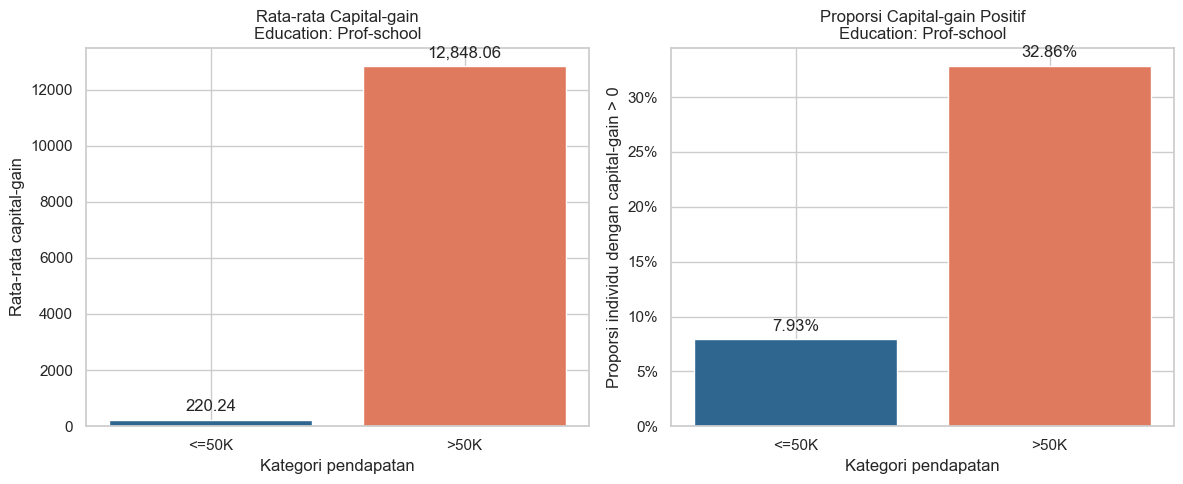

In [96]:
# Menyiapkan data visualisasi Bonus Analysis 2
education_capital_plot = (
    top_education_capital
    .reset_index()
)

income_colors = [
    COLOR_LOW_INCOME,
    COLOR_HIGH_INCOME,
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)

# Grafik rata-rata capital-gain
mean_bars = axes[0].bar(
    education_capital_plot["income_clean"],
    education_capital_plot[
        "rata_rata_capital_gain"
    ],
    color=income_colors,
)

axes[0].bar_label(
    mean_bars,
    labels=[
        f"{value:,.2f}"
        for value in education_capital_plot[
            "rata_rata_capital_gain"
        ]
    ],
    padding=4,
)

axes[0].set_title(
    f"Rata-rata Capital-gain\nEducation: {top_education}"
)

axes[0].set_xlabel("Kategori pendapatan")
axes[0].set_ylabel("Rata-rata capital-gain")

# Grafik proporsi capital-gain positif
positive_bars = axes[1].bar(
    education_capital_plot["income_clean"],
    education_capital_plot[
        "proporsi_capital_gain_positif"
    ],
    color=income_colors,
)

axes[1].bar_label(
    positive_bars,
    labels=[
        f"{value:.2%}"
        for value in education_capital_plot[
            "proporsi_capital_gain_positif"
        ]
    ],
    padding=4,
)

axes[1].set_title(
    f"Proporsi Capital-gain Positif\n"
    f"Education: {top_education}"
)

axes[1].set_xlabel("Kategori pendapatan")
axes[1].set_ylabel(
    "Proporsi individu dengan capital-gain > 0"
)

axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:.0%}"
    )
)

plt.tight_layout()
plt.show()

In [97]:
# ============================================================
# BONUS ANALYSIS 3
# Pemeriksaan kualitas data kategorikal
# ============================================================

BONUS_CATEGORICAL_COLUMNS = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]


def normalize_bonus_category(series):
    """
    Membersihkan satu fitur kategorikal dan mengubah
    nilai null, string kosong, atau tanda tanya
    menjadi kategori 'Unknown'.
    """
    cleaned = (
        series
        .astype("string")
        .str.strip()
    )

    null_mask = cleaned.isna()

    question_mark_mask = (
        cleaned
        .eq("?")
        .fillna(False)
    )

    empty_string_mask = (
        cleaned
        .eq("")
        .fillna(False)
    )

    invalid_mask = (
        null_mask
        | question_mark_mask
        | empty_string_mask
    )

    normalized = cleaned.mask(
        invalid_mask,
        "Unknown",
    )

    masks = {
        "null": null_mask,
        "question_mark": question_mark_mask,
        "empty_string": empty_string_mask,
        "total_invalid": invalid_mask,
    }

    return normalized, masks

In [98]:
# Menampung ringkasan dan daftar nilai unik
categorical_unique_records = []
categorical_unique_values = {}

for column in BONUS_CATEGORICAL_COLUMNS:
    normalized_values, invalid_masks = (
        normalize_bonus_category(
            train_raw[column]
        )
    )

    unique_values = sorted(
        normalized_values
        .dropna()
        .unique()
        .tolist()
    )

    categorical_unique_values[column] = (
        unique_values
    )

    categorical_unique_records.append({
        "column": column,
        "jumlah_kategori": len(unique_values),
        "jumlah_invalid": int(
            invalid_masks["total_invalid"].sum()
        ),
        "persentase_invalid": (
            invalid_masks["total_invalid"].mean()
        ),
    })

categorical_unique_summary = (
    pd.DataFrame(categorical_unique_records)
    .set_index("column")
)

display(
    categorical_unique_summary.style.format({
        "jumlah_kategori": "{:,.0f}",
        "jumlah_invalid": "{:,.0f}",
        "persentase_invalid": "{:.2%}",
    })
)

# Menampilkan seluruh nilai unik
for column, unique_values in (
    categorical_unique_values.items()
):
    print(
        f"\n{column} "
        f"({len(unique_values)} kategori):"
    )

    print(unique_values)

,jumlah_kategori,jumlah_invalid,persentase_invalid
column,,,
workclass,9,"2,233",5.71%
education,16,0,0.00%
marital-status,7,0,0.00%
occupation,15,"2,241",5.74%
relationship,6,0,0.00%
race,5,0,0.00%
sex,2,0,0.00%
native-country,42,688,1.76%



workclass (9 kategori):
['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Unknown', 'Without-pay']

education (16 kategori):
['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college']

marital-status (7 kategori):
['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']

occupation (15 kategori):
['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving', 'Unknown']

relationship (6 kategori):
['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']

race (5 kategori):
['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'Whit

In [99]:
# Memastikan seluruh fitur kategorikal diperiksa
assert (
    categorical_unique_summary.index.tolist()
    == BONUS_CATEGORICAL_COLUMNS
)

assert len(categorical_unique_summary) == 8

assert categorical_unique_summary[
    "jumlah_kategori"
].gt(0).all()

assert categorical_unique_summary[
    "persentase_invalid"
].between(
    0,
    1,
).all()

assert all(
    "?" not in unique_values
    for unique_values
    in categorical_unique_values.values()
)

assert all(
    "" not in unique_values
    for unique_values
    in categorical_unique_values.values()
)

print(
    "\nSeluruh nilai unik fitur kategorikal "
    "berhasil diperiksa dan diverifikasi."
)


Seluruh nilai unik fitur kategorikal berhasil diperiksa dan diverifikasi.


In [100]:
# Kolom yang secara khusus memiliki nilai tidak valid
BONUS_INVALID_COLUMNS = [
    "workclass",
    "occupation",
    "native-country",
]

bonus_invalid_records = []

for column in BONUS_INVALID_COLUMNS:
    normalized_values, invalid_masks = (
        normalize_bonus_category(
            train_raw[column]
        )
    )

    null_count = int(
        invalid_masks["null"].sum()
    )

    question_mark_count = int(
        invalid_masks["question_mark"].sum()
    )

    empty_string_count = int(
        invalid_masks["empty_string"].sum()
    )

    total_invalid_count = int(
        invalid_masks["total_invalid"].sum()
    )

    bonus_invalid_records.append({
        "column": column,
        "jumlah_null": null_count,
        "jumlah_tanda_tanya": (
            question_mark_count
        ),
        "jumlah_string_kosong": (
            empty_string_count
        ),
        "total_invalid": total_invalid_count,
        "jumlah_valid": (
            len(train_raw) - total_invalid_count
        ),
        "persentase_invalid": (
            total_invalid_count
            / len(train_raw)
        ),
    })

bonus_invalid_summary = (
    pd.DataFrame(bonus_invalid_records)
    .set_index("column")
)

display(
    bonus_invalid_summary.style.format({
        "jumlah_null": "{:,.0f}",
        "jumlah_tanda_tanya": "{:,.0f}",
        "jumlah_string_kosong": "{:,.0f}",
        "total_invalid": "{:,.0f}",
        "jumlah_valid": "{:,.0f}",
        "persentase_invalid": "{:.2%}",
    })
)

,jumlah_null,jumlah_tanda_tanya,jumlah_string_kosong,total_invalid,jumlah_valid,persentase_invalid
column,,,,,,
workclass,769,"1,464",0,"2,233","36,840",5.71%
occupation,771,"1,470",0,"2,241","36,832",5.74%
native-country,222,466,0,688,"38,385",1.76%


In [101]:
# Setiap nilai invalid hanya berada pada salah satu
# kelompok: null, tanda tanya, atau string kosong
invalid_component_total = (
    bonus_invalid_summary[
        [
            "jumlah_null",
            "jumlah_tanda_tanya",
            "jumlah_string_kosong",
        ]
    ]
    .sum(axis=1)
)

assert (
    invalid_component_total
    == bonus_invalid_summary["total_invalid"]
).all()

# Jumlah valid dan invalid harus kembali
# ke jumlah seluruh baris train
assert (
    bonus_invalid_summary["jumlah_valid"]
    + bonus_invalid_summary["total_invalid"]
    == len(train_raw)
).all()

# Hasil harus konsisten dengan pemeriksaan sebelumnya
assert (
    bonus_invalid_summary["total_invalid"]
    .equals(
        categorical_unique_summary.loc[
            BONUS_INVALID_COLUMNS,
            "jumlah_invalid",
        ]
    )
)

# Memeriksa hasil spesifik dataset
EXPECTED_INVALID_COUNTS = {
    "workclass": {
        "jumlah_null": 769,
        "jumlah_tanda_tanya": 1464,
        "jumlah_string_kosong": 0,
        "total_invalid": 2233,
    },
    "occupation": {
        "jumlah_null": 771,
        "jumlah_tanda_tanya": 1470,
        "jumlah_string_kosong": 0,
        "total_invalid": 2241,
    },
    "native-country": {
        "jumlah_null": 222,
        "jumlah_tanda_tanya": 466,
        "jumlah_string_kosong": 0,
        "total_invalid": 688,
    },
}

for column, expected_values in (
    EXPECTED_INVALID_COUNTS.items()
):
    for metric, expected_value in (
        expected_values.items()
    ):
        actual_value = int(
            bonus_invalid_summary.loc[
                column,
                metric,
            ]
        )

        assert actual_value == expected_value

print(
    "\nPemeriksaan terperinci nilai tidak valid "
    "berhasil dilakukan dan diverifikasi."
)


Pemeriksaan terperinci nilai tidak valid berhasil dilakukan dan diverifikasi.


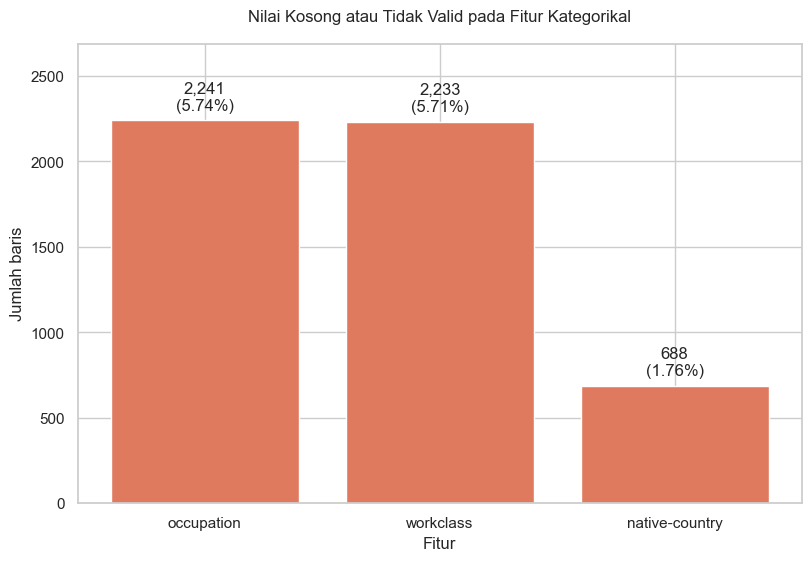

In [103]:
# Mengurutkan fitur berdasarkan jumlah invalid
invalid_plot_data = (
    bonus_invalid_summary
    .sort_values(
        "total_invalid",
        ascending=False,
    )
)

maximum_invalid = (
    invalid_plot_data["total_invalid"].max()
)

fig, ax = plt.subplots(
    figsize=(8, 5.5),
    constrained_layout=True,
)

invalid_bars = ax.bar(
    invalid_plot_data.index,
    invalid_plot_data["total_invalid"],
    color=COLOR_HIGH_INCOME,
)

ax.bar_label(
    invalid_bars,
    labels=[
        (
            f"{count:,.0f}\n"
            f"({rate:.2%})"
        )
        for count, rate in zip(
            invalid_plot_data["total_invalid"],
            invalid_plot_data["persentase_invalid"],
        )
    ],
    padding=5,
)

# Memberikan ruang untuk label di atas batang
ax.set_ylim(
    0,
    maximum_invalid * 1.20,
)

ax.set_title(
    "Nilai Kosong atau Tidak Valid "
    "pada Fitur Kategorikal",
    pad=16,
)

ax.set_xlabel("Fitur")
ax.set_ylabel("Jumlah baris")

plt.show()

In [107]:
# ============================================================
# BONUS ANALYSIS 3C
# Distribusi kombinasi education dan income
# ============================================================

# Memastikan setiap education hanya memiliki
# satu pasangan education-num
education_mapping_check = (
    bonus_data
    .groupby(
        "education_clean",
        observed=True,
    )["education-num"]
    .nunique()
)

assert education_mapping_check.eq(1).all()

# Mengurutkan kategori pendidikan berdasarkan
# nilai education-num dari tingkat rendah ke tinggi
education_order = (
    bonus_data[
        [
            "education_clean",
            "education-num",
        ]
    ]
    .drop_duplicates()
    .sort_values("education-num")
    ["education_clean"]
    .tolist()
)

assert len(education_order) == 16
assert len(set(education_order)) == 16

# Menghitung kombinasi education dan income
education_income_counts = pd.crosstab(
    index=bonus_data["education_clean"],
    columns=bonus_data["income_clean"],
    dropna=False,
)

education_income_counts = (
    education_income_counts
    .reindex(
        index=education_order,
        columns=["<=50K", ">50K"],
        fill_value=0,
    )
)

# Mengubah nama kolom agar lebih jelas
education_income_summary = (
    education_income_counts
    .rename(columns={
        "<=50K": "jumlah_<=50K",
        ">50K": "jumlah_>50K",
    })
)

education_income_summary["jumlah_total"] = (
    education_income_summary["jumlah_<=50K"]
    + education_income_summary["jumlah_>50K"]
)

education_income_summary["proporsi_<=50K"] = (
    education_income_summary["jumlah_<=50K"]
    / education_income_summary["jumlah_total"]
)

education_income_summary["proporsi_>50K"] = (
    education_income_summary["jumlah_>50K"]
    / education_income_summary["jumlah_total"]
)

# Mengatur urutan kolom
education_income_summary = (
    education_income_summary[
        [
            "jumlah_total",
            "jumlah_<=50K",
            "jumlah_>50K",
            "proporsi_<=50K",
            "proporsi_>50K",
        ]
    ]
)

print(
    "Distribusi kombinasi education dan income:"
)

education_income_summary.index.name = "education"
education_income_summary.columns.name = None

display(
    education_income_summary.style.format({
        "jumlah_total": "{:,.0f}",
        "jumlah_<=50K": "{:,.0f}",
        "jumlah_>50K": "{:,.0f}",
        "proporsi_<=50K": "{:.2%}",
        "proporsi_>50K": "{:.2%}",
    })
)

Distribusi kombinasi education dan income:


,jumlah_total,jumlah_<=50K,jumlah_>50K,proporsi_<=50K,proporsi_>50K
education,,,,,
Preschool,62,62,0,100.00%,0.00%
1st-4th,213,206,7,96.71%,3.29%
5th-6th,427,407,20,95.32%,4.68%
7th-8th,756,711,45,94.05%,5.95%
9th,611,574,37,93.94%,6.06%
10th,"1,108","1,044",64,94.22%,5.78%
11th,"1,451","1,378",73,94.97%,5.03%
12th,532,494,38,92.86%,7.14%
HS-grad,"12,582","10,592","1,990",84.18%,15.82%


In [105]:
# Jumlah seluruh kombinasi harus sama
# dengan jumlah data train
assert (
    education_income_counts
    .to_numpy()
    .sum()
    == len(bonus_data)
)

# Jumlah masing-masing kelas harus sesuai
# dengan distribusi target
assert (
    education_income_counts["<=50K"].sum()
    == int(
        bonus_data["income_clean"]
        .eq("<=50K")
        .sum()
    )
)

assert (
    education_income_counts[">50K"].sum()
    == int(
        bonus_data["income_clean"]
        .eq(">50K")
        .sum()
    )
)

# Setiap kategori harus memiliki observasi
assert education_income_summary[
    "jumlah_total"
].gt(0).all()

# Proporsi kedua kelas pada setiap baris
# harus berjumlah satu
assert np.allclose(
    (
        education_income_summary["proporsi_<=50K"]
        + education_income_summary["proporsi_>50K"]
    ),
    1.0,
)

# Pemeriksaan beberapa hasil spesifik dataset
assert (
    education_income_summary.loc[
        "Prof-school",
        "jumlah_>50K",
    ]
    == 490
)

assert (
    education_income_summary.loc[
        "Preschool",
        "jumlah_>50K",
    ]
    == 0
)

print(
    "\nDistribusi kombinasi education "
    "dan income berhasil diverifikasi."
)


Distribusi kombinasi education dan income berhasil diverifikasi.


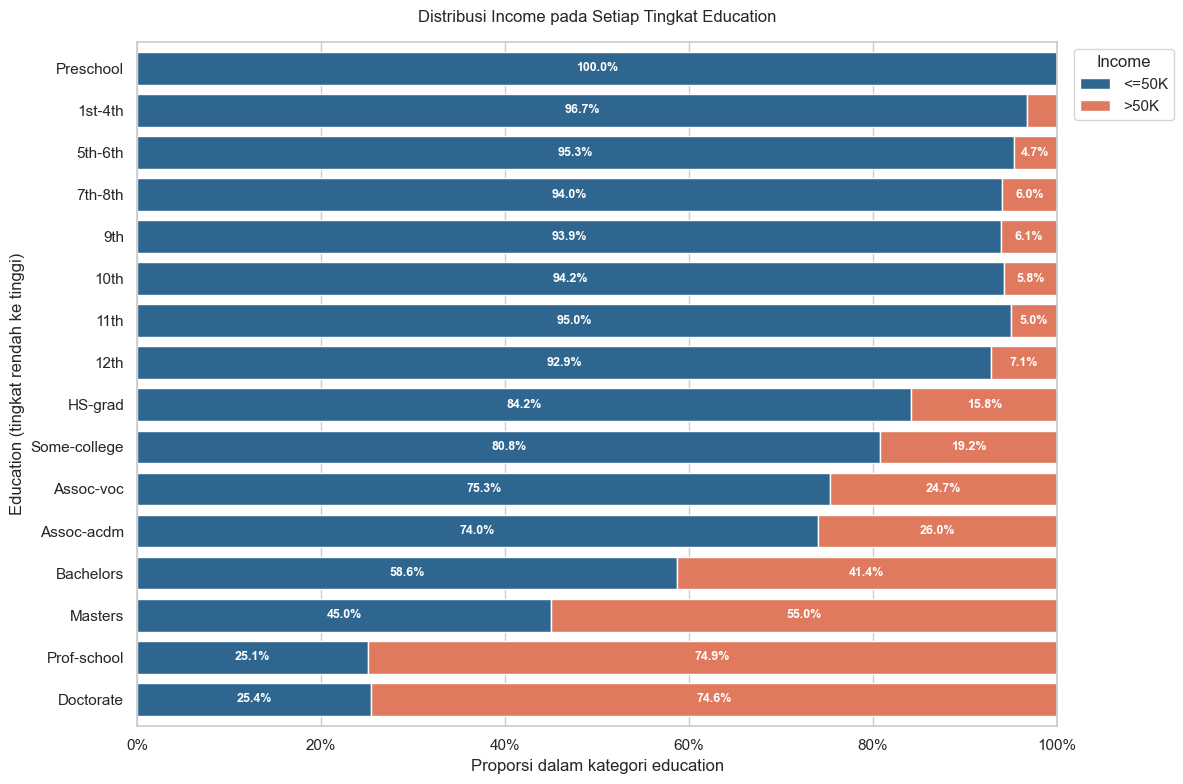

In [108]:
# Menyiapkan proporsi untuk visualisasi
education_income_plot = (
    education_income_summary[
        [
            "proporsi_<=50K",
            "proporsi_>50K",
        ]
    ]
    .rename(columns={
        "proporsi_<=50K": "<=50K",
        "proporsi_>50K": ">50K",
    })
)

fig, ax = plt.subplots(
    figsize=(12, 8),
)

education_income_plot.plot(
    kind="barh",
    stacked=True,
    color=[
        COLOR_LOW_INCOME,
        COLOR_HIGH_INCOME,
    ],
    width=0.78,
    ax=ax,
)

for container in ax.containers:
    labels = [
        (
            f"{bar.get_width():.1%}"
            if bar.get_width() >= 0.04
            else ""
        )
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "Distribusi Income pada Setiap "
    "Tingkat Education",
    pad=14,
)

ax.set_xlabel(
    "Proporsi dalam kategori education"
)

ax.set_ylabel(
    "Education (tingkat rendah ke tinggi)"
)

ax.set_xlim(0, 1)
ax.invert_yaxis()

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:.0%}"
    )
)

# Meletakkan legenda di luar area grafik
ax.legend(
    title="Income",
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
)

plt.tight_layout()
plt.show()

## Kesimpulan Akhir Notebook

### Tujuan dan Pendekatan

Notebook ini membangun model klasifikasi biner untuk memprediksi apakah pendapatan individu termasuk kategori `<=50K` atau `>50K`. Metrik utama yang digunakan adalah **F1-macro** karena metrik ini memberikan bobot yang sama terhadap kedua kelas, termasuk kelas `>50K` yang jumlah observasinya lebih sedikit.

Data train terdiri atas **39.073 observasi** dengan 14 fitur prediktor. Setelah normalisasi target, terdapat:

- **29.724 observasi (76,07%)** pada kelas `<=50K`.
- **9.349 observasi (23,93%)** pada kelas `>50K`.

Distribusi tersebut menunjukkan adanya ketidakseimbangan kelas, sehingga accuracy saja tidak cukup untuk menilai kualitas model.

### Temuan Kualitas Data dan EDA

Pemeriksaan kualitas data menemukan nilai null dan tanda tanya pada:

- `workclass`: 2.233 observasi atau 5,71%.
- `occupation`: 2.241 observasi atau 5,74%.
- `native-country`: 688 observasi atau 1,76%.

Nilai tersebut dinormalisasi menjadi kategori `Unknown`. Normalisasi ini diperlukan agar nilai kosong dan tanda tanya tidak diperlakukan sebagai kategori yang berbeda oleh encoder.

Hasil EDA memperlihatkan bahwa fitur numerik dengan hubungan paling kuat terhadap target adalah `education-num`, diikuti oleh `hours-per-week`, `age`, `capital-gain`, dan `capital-loss`. Proporsi pendapatan `>50K` secara umum meningkat pada tingkat pendidikan yang lebih tinggi.

Pemeriksaan kategori unik penting untuk menemukan inkonsistensi penulisan, kategori yang tidak terduga, dan kemungkinan category drift antara train dan test. Pemeriksaan nilai tidak valid diperlukan sebelum agregasi maupun encoding agar hasil analisis tidak bias dan pipeline dapat menangani data baru secara konsisten.

Distribusi gabungan education dan income juga menunjukkan bahwa komposisi target berbeda cukup besar pada setiap tingkat pendidikan. Informasi ini membantu memahami sinyal prediktif, ketidakseimbangan kelas dalam subkelompok, serta kategori dengan jumlah observasi yang relatif sedikit.

### Preprocessing dan Feature Engineering

Preprocessing dilakukan melalui fungsi yang dapat digunakan kembali pada train dan test. Tahap tersebut mencakup pembersihan spasi, normalisasi nilai kategorikal tidak valid, dan pemeriksaan kesesuaian struktur fitur.

Lima fitur turunan ditambahkan:

1. `capital-balance`
2. `has-capital-gain`
3. `has-capital-loss`
4. `is-married`
5. `is-us`

Jumlah fitur bertambah dari 14 menjadi **19 fitur**, yang terdiri atas 8 fitur kategorikal dan 11 fitur numerik. Nama serta urutan fitur train dan test telah diverifikasi sama.

### Eksperimen dan Pemilihan Model

Lima kandidat model dibandingkan menggunakan **5-fold Stratified Cross-Validation** dengan random seed 42:

1. Dummy Classifier
2. Logistic Regression
3. Random Forest
4. HistGradientBoosting dengan ordinal encoding
5. HistGradientBoosting dengan target encoding

Seluruh evaluasi dilakukan menggunakan prediksi **out-of-fold**. Selain model individual, dua kombinasi ensemble juga dibandingkan. Threshold klasifikasi dicari pada rentang 0,20 sampai 0,70 berdasarkan F1-macro OOF.

Model terbaik adalah **Ensemble HGB**, yaitu rata-rata probabilitas dari:

- 50% HistGradientBoosting dengan ordinal encoding.
- 50% HistGradientBoosting dengan target encoding.

Threshold optimal yang diperoleh adalah **0,450**.

### Evaluasi Model Terpilih

| Metrik OOF | Nilai |
|---|---:|
| Accuracy | 0,8714 |
| Balanced accuracy | 0,8140 |
| F1-macro | 0,8199 |
| ROC-AUC | 0,9283 |
| Precision kelas `<=50K` | 0,9085 |
| Recall kelas `<=50K` | 0,9240 |
| F1 kelas `<=50K` | 0,9162 |
| Precision kelas `>50K` | 0,7445 |
| Recall kelas `>50K` | 0,7040 |
| F1 kelas `>50K` | 0,7237 |

Confusion matrix OOF menghasilkan:

- True Negative: 27.465
- False Positive: 2.259
- False Negative: 2.767
- True Positive: 6.582

Hasil tersebut menunjukkan bahwa model dapat memisahkan kedua kelas dengan baik, tetapi kelas `>50K` masih lebih sulit diprediksi. Recall kelas `>50K` sebesar 70,40% berarti masih terdapat 2.767 individu berpendapatan `>50K` yang diprediksi sebagai `<=50K`.

### Hasil Bonus Analysis

Occupation dengan proporsi pendapatan `>50K` tertinggi adalah **Exec-managerial**, dengan:

- 2.312 dari 4.893 observasi berada pada kelas `>50K`.
- Proporsi pendapatan `>50K` sebesar 47,25%.
- Rata-rata jam kerja kelas `<=50K` sebesar 42,69 jam per minggu.
- Rata-rata jam kerja kelas `>50K` sebesar 47,43 jam per minggu.
- Selisih rata-rata sebesar 4,74 jam per minggu.

Education dengan proporsi pendapatan `>50K` tertinggi adalah **Prof-school**, dengan:

- 490 dari 654 observasi berada pada kelas `>50K`.
- Proporsi pendapatan `>50K` sebesar 74,92%.
- Rata-rata `capital-gain` kelas `<=50K` sebesar 220,24.
- Rata-rata `capital-gain` kelas `>50K` sebesar 12.848,06.
- Selisih rata-rata sebesar 12.627,82.

Median `capital-gain` pada kedua kelas tetap nol. Hal ini menunjukkan bahwa distribusi `capital-gain` sangat tidak simetris dan rata-ratanya dipengaruhi oleh sebagian kecil observasi bernilai besar. Oleh karena itu, interpretasi sebaiknya menggunakan rata-rata, median, dan proporsi nilai positif secara bersamaan.

### Rekomendasi

Perusahaan atau institusi pelatihan dapat mempertimbangkan investasi pada program yang mengembangkan keterampilan profesional, spesialisasi teknis, kepemimpinan, dan kemampuan manajerial. Program tersebut dapat diprioritaskan berdasarkan kebutuhan kompetensi pekerjaan dan dievaluasi menggunakan hasil sebelum dan sesudah pelatihan.

Namun, hasil ini merupakan hubungan statistik pada data observasional dan tidak membuktikan hubungan sebab-akibat. Education, occupation, jam kerja, maupun capital-gain tidak boleh digunakan sebagai satu-satunya dasar pengambilan keputusan terhadap individu. Penggunaan atribut sensitif seperti sex dan race juga memerlukan evaluasi fairness agar model tidak memperkuat ketimpangan yang terdapat pada data historis.

### Prediksi Test dan Submission

Model final dilatih kembali menggunakan seluruh data train, kemudian digunakan untuk memprediksi 9.769 observasi test dengan threshold 0,450. Distribusi prediksi akhir adalah:

- `<=50K`: 7.605 observasi atau 77,85%.
- `>50K`: 2.164 observasi atau 22,15%.

File submission telah diverifikasi memiliki tepat dua kolom, yaitu `id` dan `income`, mempertahankan urutan ID test, tidak memiliki nilai kosong, tidak memiliki kolom tambahan, dan hanya menggunakan label yang diizinkan.

Isi file submission akhir juga identik dengan submission sebelumnya yang memperoleh skor leaderboard **0,824224 atau 82,4224%**. Meskipun demikian, pemilihan model dalam notebook tetap didasarkan pada evaluasi out-of-fold, bukan pada leaderboard.

### Keterbatasan dan Pengembangan Selanjutnya

Beberapa pengembangan yang dapat dilakukan adalah:

- Hyperparameter tuning yang lebih luas.
- Repeated atau nested cross-validation.
- Kalibrasi probabilitas.
- Cost-sensitive learning untuk meningkatkan recall kelas `>50K`.
- Pengujian stabilitas threshold pada beberapa pembagian data.
- Evaluasi fairness pada kelompok demografis.
- Pemantauan category drift ketika model digunakan pada data baru.

Secara keseluruhan, Ensemble HGB memberikan performa terbaik dan stabil berdasarkan F1-macro OOF. Pipeline yang dibuat telah mencakup EDA, preprocessing, feature engineering, eksperimen model, optimasi threshold, evaluasi rinci, prediksi test, dan pemeriksaan format submission secara reproducible.